# Flood Risk ML Project: Complete Consolidated Notebook

This single notebook combines the project workflow, code, models, metrics, and supporting ML concepts covered across the repository notebooks and source files.

## Covered Concepts

This notebook covers:

- Jupyter and environment setup
- Virtual environments and `requirements.txt`
- ML project folder structure
- Separating loading, training, evaluation, and inference logic
- Supervised learning problem types
- Binary classification, multi-class, multi-label, and regression framing
- Defining features and target variables
- EDA and feature distribution inspection
- Missing values, data quality, outliers, skew, and class balance
- Train/test splitting and stratification
- Data leakage prevention and prediction-time feature validity
- `StandardScaler`, `MinMaxScaler`, `SimpleImputer`, `OneHotEncoder`, `ColumnTransformer`, and `Pipeline`
- Feature engineering helpers
- `DummyClassifier`, `RandomForestClassifier`, `LogisticRegression`, `KNeighborsClassifier`, `DecisionTreeClassifier`
- `DummyRegressor`, `LinearRegression`, and `DecisionTreeRegressor`
- Cross-validation, `GridSearchCV`, and learning curves
- Gini impurity, entropy, information gain, and variance reduction
- Accuracy, precision, recall, F1, macro/micro/weighted F1, confusion matrix, normalized confusion matrix, ROC-AUC, ROC curve, precision-recall curve
- MAE, MSE, RMSE, and R2 for regression
- Model persistence with `joblib`
- Single-row and batch prediction workflows
- Artifact saving, reports, and feature importance
- Impurity-based importance versus permutation importance
- Bias, variance, overfitting, and underfitting

## Setup And Reproducibility

Recommended shell setup outside the notebook:

```bash
python3 -m venv venv
source venv/bin/activate
pip install -r requirements.txt
pip install jupyter matplotlib seaborn
```

Recommended project layout:

- `data/raw/`
- `data/processed/`
- `src/`
- `models/`
- `reports/`
- `notebooks/`
- `requirements.txt`

In [1]:
# This imports the libraries used across the complete workflow.
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_absolute_error, mean_squared_error, precision_recall_curve, precision_score, r2_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score, cross_validate, learning_curve, train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.utils.class_weight import compute_class_weight
from sklearn.datasets import make_classification
from scipy.stats import randint, loguniform

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# This defines the project paths and main configuration values.
PROJECT_ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'flood_data.csv'
PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'flood_data_processed.csv'
MODEL_PATH = PROJECT_ROOT / 'models' / 'flood_prediction_model.pkl'
SCALER_PATH = PROJECT_ROOT / 'models' / 'scaler.pkl'
REPORT_PATH = PROJECT_ROOT / 'reports' / 'evaluation_report.txt'
FEATURE_IMPORTANCE_PATH = PROJECT_ROOT / 'reports' / 'feature_importance.csv'
FEATURE_COLUMNS = ['rainfall', 'temperature', 'humidity', 'river_level', 'soil_moisture']
TARGET_COLUMN = 'flood_risk'
TEST_SIZE = 0.2
MISSING_VALUE_THRESHOLD = 0.5
for folder in [PROJECT_ROOT / 'data' / 'processed', PROJECT_ROOT / 'models', PROJECT_ROOT / 'reports']:
    folder.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)
print(RAW_DATA_PATH)

/Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning
/Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/data/raw/flood_data.csv


## Problem Framing

This repository mainly solves a **supervised binary classification** problem: predict `flood_risk` using environmental features.

Other problem types discussed in the original notebooks:

- Regression
- Multi-class classification
- Multi-label classification

Target design rules:

- It must be measurable.
- It must exist historically in the data.
- It must be available for model training.
- It must match the decision we want to support.

Feature design rules:

- Use only columns available at prediction time.
- Do not leak future information.
- Prefer explicit feature lists over using every column blindly.

In [3]:
# This loads the flood dataset and previews its structure.
data = pd.read_csv(RAW_DATA_PATH)
print('Shape:', data.shape)
display(data.head())
display(data.dtypes)

Shape: (51, 6)


,rainfall,temperature,humidity,river_level,soil_moisture,flood_risk
0,23.5,18.2,45.0,1.2,0.35,0
1,34.2,22.1,52.0,1.8,0.42,0
2,45.6,25.3,65.0,2.5,0.48,1
3,28.3,20.5,48.0,1.5,0.38,0
4,52.1,28.1,72.0,3.2,0.55,1


rainfall         float64
temperature      float64
humidity         float64
river_level      float64
soil_moisture    float64
flood_risk         int64
dtype: object

## Define Features And Target

Main classification features:

- `rainfall`
- `temperature`
- `humidity`
- `river_level`
- `soil_moisture`

Target:

- `flood_risk`

Positive class:

- `1` means flood risk

Negative class:

- `0` means no flood

In [4]:
# This checks that the required feature and target columns exist.
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in data.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')
X = data[FEATURE_COLUMNS].copy()
y = data[TARGET_COLUMN].copy()
display(X.head())
display(y.head())

,rainfall,temperature,humidity,river_level,soil_moisture
0,23.5,18.2,45.0,1.2,0.35
1,34.2,22.1,52.0,1.8,0.42
2,45.6,25.3,65.0,2.5,0.48
3,28.3,20.5,48.0,1.5,0.38
4,52.1,28.1,72.0,3.2,0.55


0    0
1    0
2    1
3    0
4    1
Name: flood_risk, dtype: int64

## Exploratory Data Analysis

EDA tasks covered in the original notebooks:

- dataset shape and column inspection
- dtypes and data quality
- missing values
- summary statistics
- target distribution
- feature histograms
- feature-vs-target views
- correlation analysis

In [5]:
# This summarizes the dataset before preprocessing.
display(data.info())
display(data.describe(include='all'))
display(data.isnull().sum())
display(y.value_counts(normalize=True).rename('class_ratio'))

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rainfall       51 non-null     float64
 1   temperature    51 non-null     float64
 2   humidity       51 non-null     float64
 3   river_level    51 non-null     float64
 4   soil_moisture  51 non-null     float64
 5   flood_risk     51 non-null     int64  
dtypes: float64(5), int64(1)
memory usage: 2.5 KB


None

,rainfall,temperature,humidity,river_level,soil_moisture,flood_risk
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,37.890196,23.343137,57.800000,2.151765,0.447255,0.490196
std,12.404390,4.388223,11.886379,0.863400,0.085676,0.504878
min,18.900000,16.500000,41.000000,1.000000,0.310000,0.000000
25%,26.100000,19.150000,46.750000,1.365000,0.375000,0.000000
50%,34.200000,22.400000,52.500000,1.800000,0.430000,0.000000
75%,48.550000,27.350000,70.250000,3.025000,0.520000,1.000000
max,58.400000,30.100000,76.000000,3.600000,0.590000,1.000000


rainfall         0
temperature      0
humidity         0
river_level      0
soil_moisture    0
flood_risk       0
dtype: int64

flood_risk
0    0.509804
1    0.490196
Name: class_ratio, dtype: float64

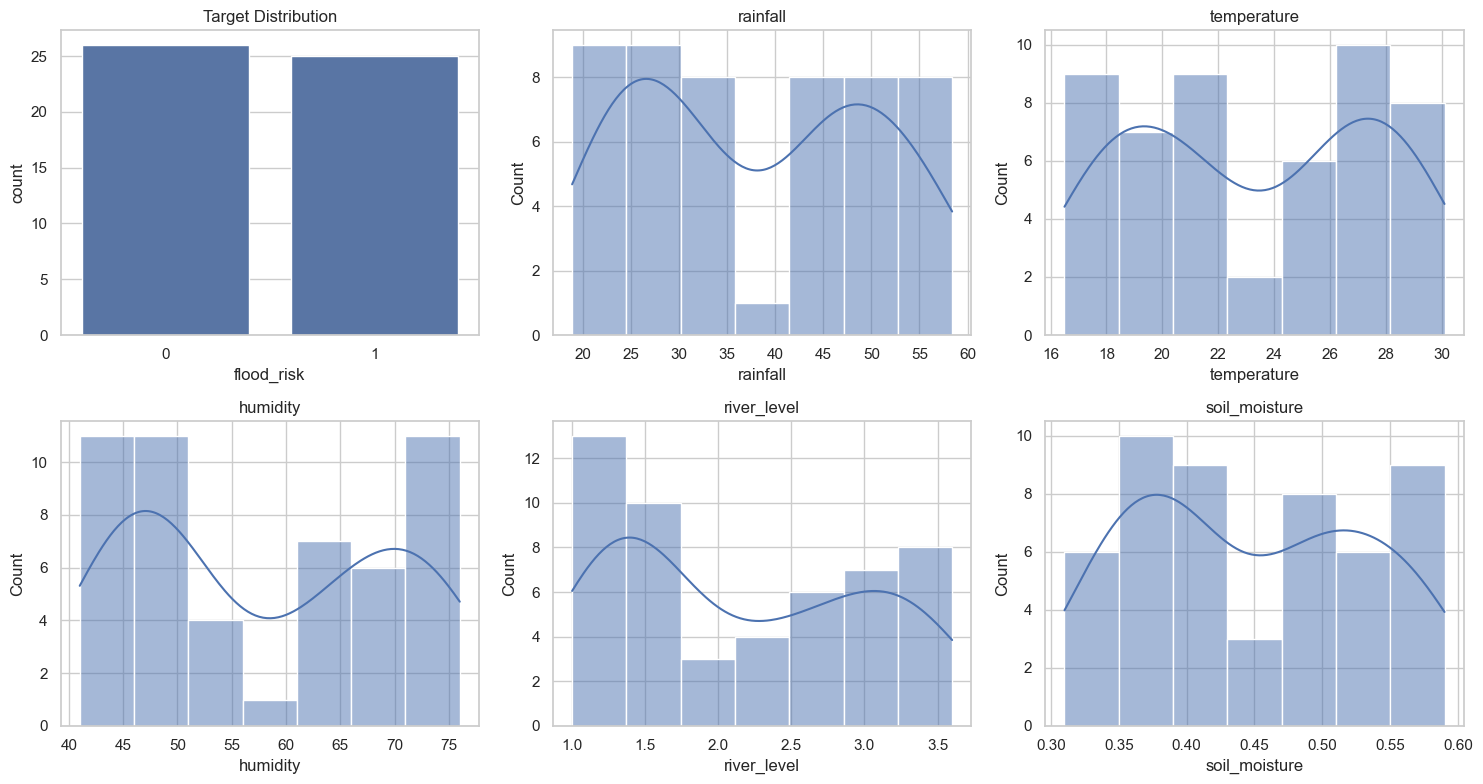

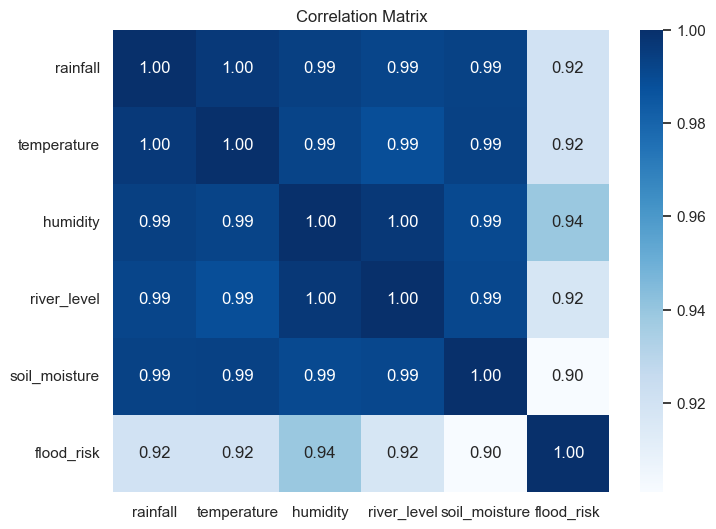

In [6]:
# This visualizes target balance, feature distributions, and correlations.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.countplot(x=y, ax=axes[0, 0])
axes[0, 0].set_title('Target Distribution')
for axis, column in zip(axes.flat[1:], FEATURE_COLUMNS):
    sns.histplot(data[column], kde=True, ax=axis)
    axis.set_title(column)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(data[FEATURE_COLUMNS + [TARGET_COLUMN]].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Inspect Feature Distributions Before Modeling

Distribution-focused concepts from the notebooks:

- min, max, mean, median, std, and percentiles
- skewness and long tails
- multimodality
- outliers and IQR checks
- rare categories and label consistency
- comparing distributions by target class
- deciding whether scaling or transforms are needed
- possible transforms like log, square root, Box-Cox, clipping, and winsorization

,feature,skew,median,outliers_iqr
0,rainfall,0.100546,34.20,0
1,temperature,-0.017722,22.40,0
2,humidity,0.143128,52.50,0
3,river_level,0.257898,1.80,0
4,soil_moisture,0.125038,0.43,0


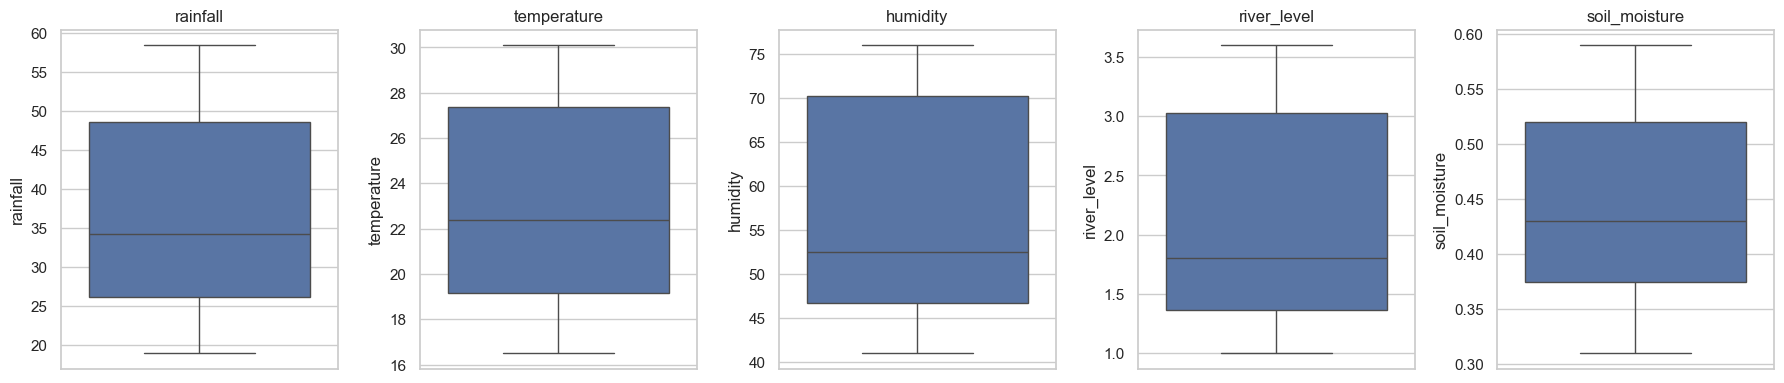

In [7]:
# This measures skewness and simple IQR-based outlier counts.
distribution_summary = []
for column in FEATURE_COLUMNS:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((data[column] < lower) | (data[column] > upper)).sum()
    distribution_summary.append({
        'feature': column,
        'skew': data[column].skew(),
        'median': data[column].median(),
        'outliers_iqr': int(outlier_count)
    })
distribution_summary = pd.DataFrame(distribution_summary)
display(distribution_summary)

fig, axes = plt.subplots(1, len(FEATURE_COLUMNS), figsize=(18, 4))
for axis, column in zip(axes, FEATURE_COLUMNS):
    sns.boxplot(y=data[column], ax=axis)
    axis.set_title(column)
plt.tight_layout()
plt.show()

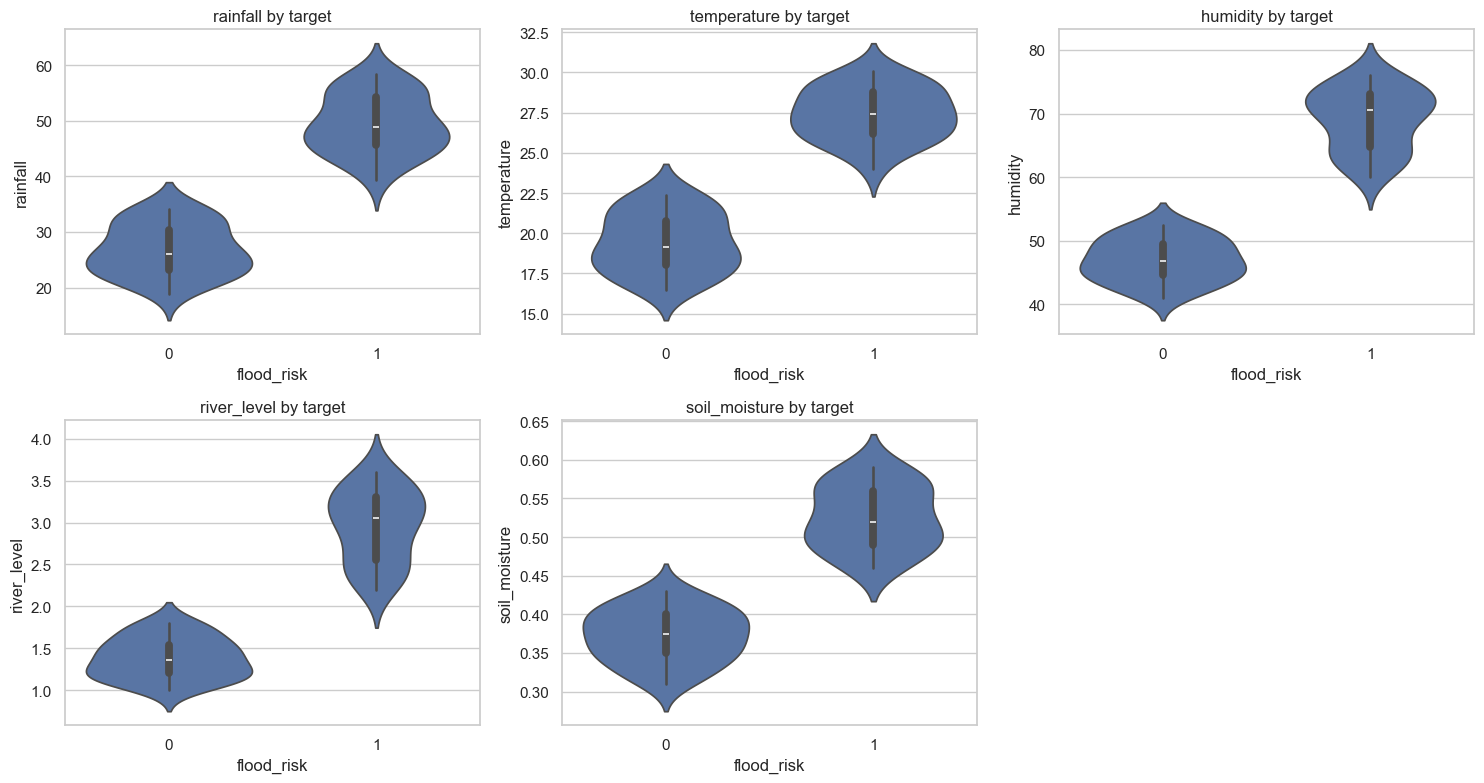

In [8]:
# This compares feature distributions across the target classes.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, column in zip(axes.flat, FEATURE_COLUMNS):
    sns.violinplot(data=data, x=TARGET_COLUMN, y=column, ax=axis)
    axis.set_title(f'{column} by target')
axes[-1, -1].axis('off')
plt.tight_layout()
plt.show()

## Data Leakage Prevention And Splitting

Important leakage concepts from the notebooks:

- Split the data before fitting preprocessing steps.
- Keep the test set untouched until evaluation.
- Avoid target leakage and train-test contamination.
- Use stratification for classification when class balance matters.
- Use time-based splits for temporal datasets.
- Ask whether a feature would be known at the prediction moment.

In [9]:
# This cleans missing values and prepares a leakage-safe split.
clean_data = data.copy()
missing_ratio = clean_data.isnull().sum() / len(clean_data)
drop_columns = missing_ratio[missing_ratio > MISSING_VALUE_THRESHOLD].index.tolist()
if drop_columns:
    clean_data = clean_data.drop(columns=drop_columns)
for column in clean_data.select_dtypes(include=[np.number]).columns:
    if clean_data[column].isnull().any():
        clean_data[column] = clean_data[column].fillna(clean_data[column].mean())
X = clean_data[FEATURE_COLUMNS].copy()
y = clean_data[TARGET_COLUMN].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(40, 5) (11, 5) (40,) (11,)


## Preprocessing Techniques

Main preprocessing ideas covered in the original notebooks:

- mean filling for numeric missing values
- median imputation
- most-frequent imputation
- `StandardScaler`
- `MinMaxScaler`
- `OneHotEncoder`
- `ColumnTransformer`
- reusable `Pipeline` objects
- saving preprocessing artifacts for inference reuse

In [10]:
# This fits the main StandardScaler on training data only.
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[FEATURE_COLUMNS] = scaler.fit_transform(X_train[FEATURE_COLUMNS])
X_test_scaled[FEATURE_COLUMNS] = scaler.transform(X_test[FEATURE_COLUMNS])
joblib.dump(scaler, SCALER_PATH)
clean_data.to_csv(PROCESSED_DATA_PATH, index=False)
display(X_train_scaled.head())

,rainfall,temperature,humidity,river_level,soil_moisture
0,-1.143465,-1.142634,-1.064773,-1.095493,-1.105959
15,-0.972312,-0.982745,-0.979829,-0.977444,-0.870648
30,0.722918,0.821715,0.888939,0.852312,0.658869
10,0.869620,0.935921,1.058827,1.029385,0.894180
29,-1.176066,-1.188317,-1.107245,-1.154517,-1.105959


In [11]:
# This builds an alternate mixed-type preprocessing pipeline example.
numerical_cols = FEATURE_COLUMNS
categorical_cols = []
numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', MinMaxScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_pipeline, numerical_cols), ('cat', categorical_pipeline, categorical_cols)], remainder='drop')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Feature Engineering Utilities

The source code includes additional feature engineering utilities that were not fully covered in the original notebook sequence:

- interaction features
- polynomial features
- rolling mean and rolling standard deviation
- min-max normalization helper
- manual feature selection helper

In [12]:
# This defines optional feature engineering helpers for experiments.
def create_interaction_features(frame):
    frame = frame.copy()
    if 'rainfall' in frame.columns and 'humidity' in frame.columns:
        frame['rainfall_humidity_interaction'] = frame['rainfall'] * frame['humidity']
    if 'temperature' in frame.columns and 'river_level' in frame.columns:
        frame['temp_river_interaction'] = frame['temperature'] * frame['river_level']
    return frame

def create_polynomial_features(frame, columns, degree=2):
    frame = frame.copy()
    for column in columns:
        if column in frame.columns:
            for power in range(2, degree + 1):
                suffix = 'squared' if power == 2 else f'power_{power}'
                frame[f'{column}_{suffix}'] = frame[column] ** power
    return frame

def create_statistical_features(frame, window_size=3):
    frame = frame.copy()
    for column in frame.select_dtypes(include=[np.number]).columns:
        frame[f'{column}_rolling_mean'] = frame[column].rolling(window=window_size, min_periods=1).mean()
        frame[f'{column}_rolling_std'] = frame[column].rolling(window=window_size, min_periods=1).std().fillna(0)
    return frame

def normalize_feature(frame, column):
    frame = frame.copy()
    min_val = frame[column].min()
    max_val = frame[column].max()
    if max_val != min_val:
        frame[f'{column}_normalized'] = (frame[column] - min_val) / (max_val - min_val)
    return frame

def select_features(frame, feature_list):
    available_features = [feature for feature in feature_list if feature in frame.columns]
    return frame[available_features].copy()

engineered_preview = create_interaction_features(clean_data[FEATURE_COLUMNS])
engineered_preview = create_polynomial_features(engineered_preview, ['rainfall', 'river_level'])
display(engineered_preview.head())

,rainfall,temperature,humidity,river_level,soil_moisture,rainfall_humidity_interaction,temp_river_interaction,rainfall_squared,river_level_squared
0,23.5,18.2,45.0,1.2,0.35,1057.5,21.84,552.25,1.44
1,34.2,22.1,52.0,1.8,0.42,1778.4,39.78,1169.64,3.24
2,45.6,25.3,65.0,2.5,0.48,2964.0,63.25,2079.36,6.25
3,28.3,20.5,48.0,1.5,0.38,1358.4,30.75,800.89,2.25
4,52.1,28.1,72.0,3.2,0.55,3751.2,89.92,2714.41,10.24


## Baseline Models And Main Classification Models

Models covered across the original notebooks:

- `DummyClassifier`
- `RandomForestClassifier`
- `LogisticRegression`
- `KNeighborsClassifier`
- `DecisionTreeClassifier`

The main production-style pipeline in this project uses `RandomForestClassifier`.

In [13]:
# This trains the baseline and main classification models.
models = {
    'dummy_baseline': DummyClassifier(strategy='most_frequent'),
    'random_forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'logistic_regression': LogisticRegression(random_state=RANDOM_STATE),
    'knn': KNeighborsClassifier(n_neighbors=5),
    'decision_tree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
}

trained_models = {}
model_predictions = {}
model_probabilities = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    model_predictions[name] = model.predict(X_test_scaled)
    if hasattr(model, 'predict_proba'):
        model_probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]
list(trained_models.keys())

['dummy_baseline',
 'random_forest',
 'logistic_regression',
 'knn',
 'decision_tree']

In [14]:
# This compares model accuracy, precision, recall, and F1.
comparison_rows = []
for name, predictions in model_predictions.items():
    comparison_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions, zero_division=0),
        'recall': recall_score(y_test, predictions, zero_division=0),
        'f1': f1_score(y_test, predictions, zero_division=0)
    })
comparison_df = pd.DataFrame(comparison_rows).sort_values('f1', ascending=False)
display(comparison_df)

,model,accuracy,precision,recall,f1
1,random_forest,1.000000,1.0,1.0,1.0
2,logistic_regression,1.000000,1.0,1.0,1.0
3,knn,1.000000,1.0,1.0,1.0
4,decision_tree,1.000000,1.0,1.0,1.0
0,dummy_baseline,0.545455,0.0,0.0,0.0


## Improving Model Performance Using GridSearchCV

Hyperparameters are model settings chosen before training that control complexity, regularization, and the bias-variance trade-off.

Examples:

- `n_neighbors` in KNN
- `max_depth` in Decision Trees
- `C` in Logistic Regression
- `n_estimators` in Random Forest

Why tuning matters:

- too restrictive leads to underfitting
- too flexible leads to overfitting
- the right values are data-dependent and must be searched

What GridSearchCV does:

- defines a search grid
- evaluates every hyperparameter combination
- uses cross-validation on the training set only
- selects the best mean validation score
- refits the best configuration on the full training data

Key rule:

- tune on training data only and evaluate on the test set exactly once after tuning is complete

In [15]:
# This tunes KNN with a leakage-safe pipeline and compares it to baseline and defaults.
knn_pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
knn_baseline = DummyClassifier(strategy='most_frequent')
knn_baseline.fit(X_train, y_train)
baseline_f1 = f1_score(y_test, knn_baseline.predict(X_test), zero_division=0)
untuned_knn = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5, weights='uniform'))])
untuned_knn.fit(X_train, y_train)
untuned_f1 = f1_score(y_test, untuned_knn.predict(X_test), zero_division=0)
knn_param_grid = {'knn__n_neighbors': range(1, 21), 'knn__weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=5, scoring='f1', return_train_score=True, n_jobs=-1)
knn_grid.fit(X_train, y_train)
best_knn_model = knn_grid.best_estimator_
best_knn_pred = best_knn_model.predict(X_test)
best_knn_test_f1 = f1_score(y_test, best_knn_pred, zero_division=0)
print('Baseline F1:', baseline_f1)
print('Untuned KNN F1:', untuned_f1)
print('Best Parameters:', knn_grid.best_params_)
print('Best CV F1:', knn_grid.best_score_)
print('Test F1:', best_knn_test_f1)
print(classification_report(y_test, best_knn_pred, target_names=['No Flood', 'Flood']))

Baseline F1: 0.0
Untuned KNN F1: 1.0
Best Parameters: {'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Best CV F1: 1.0
Test F1: 1.0
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [16]:
# This reviews the top KNN GridSearchCV configurations.
knn_results_df = pd.DataFrame(knn_grid.cv_results_)[['param_knn__n_neighbors', 'param_knn__weights', 'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']]
display(knn_results_df.sort_values('rank_test_score').head(10))

,param_knn__n_neighbors,param_knn__weights,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,1,uniform,1.0,1.0,0.0,1
22,12,uniform,1.0,1.0,0.0,1
23,12,distance,1.0,1.0,0.0,1
24,13,uniform,1.0,1.0,0.0,1
25,13,distance,1.0,1.0,0.0,1
26,14,uniform,1.0,1.0,0.0,1
27,14,distance,1.0,1.0,0.0,1
28,15,uniform,1.0,1.0,0.0,1
21,11,distance,1.0,1.0,0.0,1
29,15,distance,1.0,1.0,0.0,1


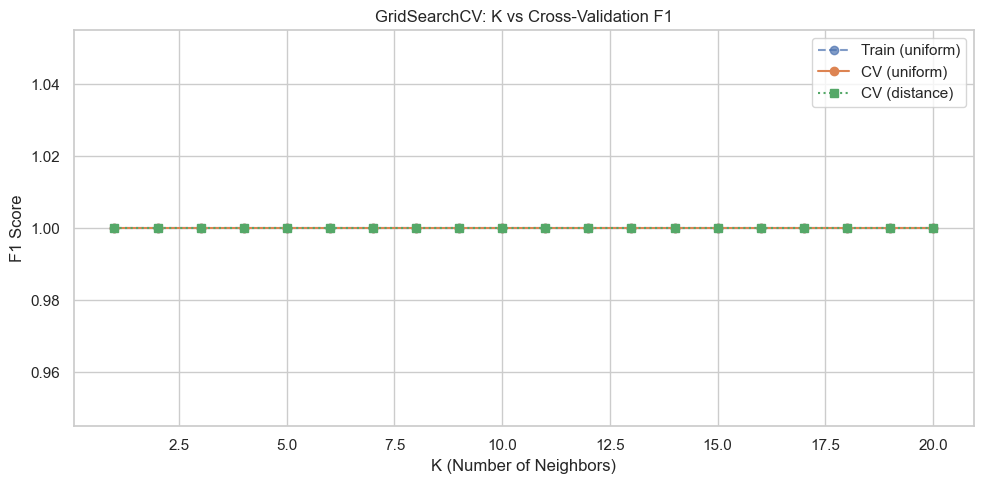

In [17]:
# This plots train and cross-validation F1 across K values.
uniform_mask = knn_results_df['param_knn__weights'] == 'uniform'
distance_mask = knn_results_df['param_knn__weights'] == 'distance'
k_values = knn_results_df[uniform_mask]['param_knn__n_neighbors'].astype(int)
plt.figure(figsize=(10, 5))
plt.plot(k_values, knn_results_df[uniform_mask]['mean_train_score'], label='Train (uniform)', linestyle='--', marker='o', alpha=0.7)
plt.plot(k_values, knn_results_df[uniform_mask]['mean_test_score'], label='CV (uniform)', marker='o')
plt.plot(k_values, knn_results_df[distance_mask]['mean_test_score'], label='CV (distance)', marker='s', linestyle=':')
plt.fill_between(k_values, knn_results_df[uniform_mask]['mean_test_score'] - knn_results_df[uniform_mask]['std_test_score'], knn_results_df[uniform_mask]['mean_test_score'] + knn_results_df[uniform_mask]['std_test_score'], alpha=0.15)
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('F1 Score')
plt.title('GridSearchCV: K vs Cross-Validation F1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Why The Scoring Metric Matters

GridSearchCV picks the hyperparameters that maximize the chosen scoring metric. On imbalanced problems, accuracy can be misleading, so metrics like F1, precision, recall, or ROC-AUC are often better.

Examples:

- balanced classification: `accuracy`
- imbalanced classification: `f1` or `roc_auc`
- false negatives costly: `recall`
- false positives costly: `precision`
- regression: `neg_mean_squared_error` or `r2`

In [18]:
# This tunes a Decision Tree with GridSearchCV using F1 scoring.
tree_param_grid_demo = {'max_depth': [2, 4, 6, 8, 10, None], 'min_samples_leaf': [1, 5, 10, 20], 'criterion': ['gini', 'entropy']}
tree_grid_demo = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), tree_param_grid_demo, cv=5, scoring='f1', return_train_score=True, n_jobs=-1)
tree_grid_demo.fit(X_train, y_train)
tree_demo_pred = tree_grid_demo.best_estimator_.predict(X_test)
print('Best Decision Tree Parameters:', tree_grid_demo.best_params_)
print('Best Decision Tree CV F1:', tree_grid_demo.best_score_)
print('Decision Tree Test F1:', f1_score(y_test, tree_demo_pred, zero_division=0))
print(classification_report(y_test, tree_demo_pred, target_names=['No Flood', 'Flood']))

Best Decision Tree Parameters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1}
Best Decision Tree CV F1: 1.0
Decision Tree Test F1: 1.0
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



## Improving Model Performance Using RandomizedSearchCV

GridSearchCV is exhaustive, but it scales poorly as the number of hyperparameters grows. RandomizedSearchCV solves that by sampling a fixed number of configurations from specified distributions.

Why random search is efficient:

- it avoids the combinatorial explosion of full grids
- it explores important dimensions more efficiently when only a few hyperparameters really matter
- it works naturally with continuous ranges
- compute grows roughly linearly with `n_iter`, not exponentially with parameter count

Use RandomizedSearchCV when:

- you have 4 or more hyperparameters
- parameter ranges are wide
- the model is expensive to train
- you want broad exploration before doing a fine grid search

In [19]:
# This tunes a Random Forest with RandomizedSearchCV.
rf_search_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': randint(2, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 15),
    'max_features': ['sqrt', 'log2', None]
}
rf_random_search = RandomizedSearchCV(rf_search_model, param_distributions=rf_param_dist, n_iter=30, cv=5, scoring='accuracy', random_state=RANDOM_STATE, return_train_score=True, n_jobs=-1)
rf_random_search.fit(X_train, y_train)
rf_random_pred = rf_random_search.best_estimator_.predict(X_test)
print('Best Parameters:', rf_random_search.best_params_)
print('Best CV Score:', rf_random_search.best_score_)
print('Test Accuracy:', accuracy_score(y_test, rf_random_pred))
print(classification_report(y_test, rf_random_pred, target_names=['No Flood', 'Flood']))

Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'min_samples_split': 9, 'n_estimators': 238}
Best CV Score: 1.0
Test Accuracy: 1.0
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



### Choosing `n_iter`

`n_iter` controls how many random configurations are evaluated. Larger search spaces need more iterations. A practical way to judge adequacy is to see when the best CV score stops improving much as `n_iter` increases.

,n_iter,best_cv_score
0,10,1.0
1,20,1.0
2,30,1.0
3,40,1.0


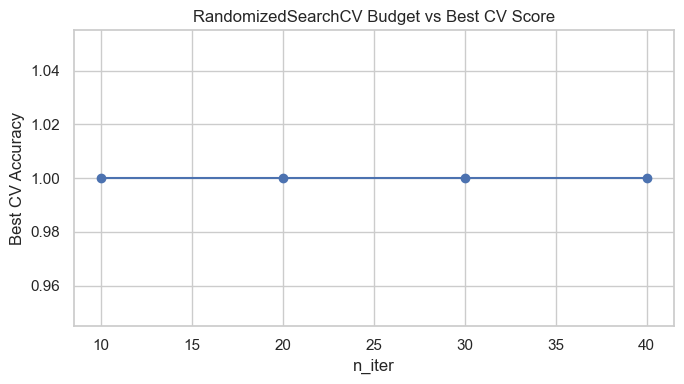

In [20]:
# This tracks best CV score as the randomized search budget increases.
cv_scores_by_iter = []
for n in [10, 20, 30, 40]:
    rs = RandomizedSearchCV(rf_search_model, rf_param_dist, n_iter=n, cv=5, scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
    rs.fit(X_train, y_train)
    cv_scores_by_iter.append((n, rs.best_score_))
iter_results_df = pd.DataFrame(cv_scores_by_iter, columns=['n_iter', 'best_cv_score'])
display(iter_results_df)
plt.figure(figsize=(7, 4))
plt.plot(iter_results_df['n_iter'], iter_results_df['best_cv_score'], marker='o')
plt.xlabel('n_iter')
plt.ylabel('Best CV Accuracy')
plt.title('RandomizedSearchCV Budget vs Best CV Score')
plt.grid(True)
plt.tight_layout()
plt.show()

### Parameter Distributions

Common choices:

- `randint` for integer hyperparameters like `n_estimators`, `max_depth`, or `n_neighbors`
- `loguniform` for regularization or learning-rate style parameters that span orders of magnitude
- lists for categorical choices like `max_features`

Use `loguniform` when scale matters more than absolute difference, such as `C` in Logistic Regression.

In [21]:
# This tunes Logistic Regression with a log-uniform regularization search.
logreg_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000))])
logreg_param_dist = {'model__C': loguniform(1e-4, 1e2), 'model__penalty': ['l2']}
logreg_random_search = RandomizedSearchCV(logreg_pipeline, param_distributions=logreg_param_dist, n_iter=25, cv=5, scoring='f1', random_state=RANDOM_STATE, n_jobs=-1)
logreg_random_search.fit(X_train, y_train)
logreg_random_pred = logreg_random_search.best_estimator_.predict(X_test)
print('Best Logistic Regression Parameters:', logreg_random_search.best_params_)
print('Best Logistic Regression CV F1:', logreg_random_search.best_score_)
print('Logistic Regression Test F1:', f1_score(y_test, logreg_random_pred, zero_division=0))

Best Logistic Regression Parameters: {'model__C': np.float64(0.017670169402947963), 'model__penalty': 'l2'}
Best Logistic Regression CV F1: 1.0
Logistic Regression Test F1: 1.0


### Visualizing Randomized Search Results

Random search creates a cloud of tried configurations rather than a structured grid. Plotting score versus sampled hyperparameters helps reveal which dimensions matter and where performance plateaus.

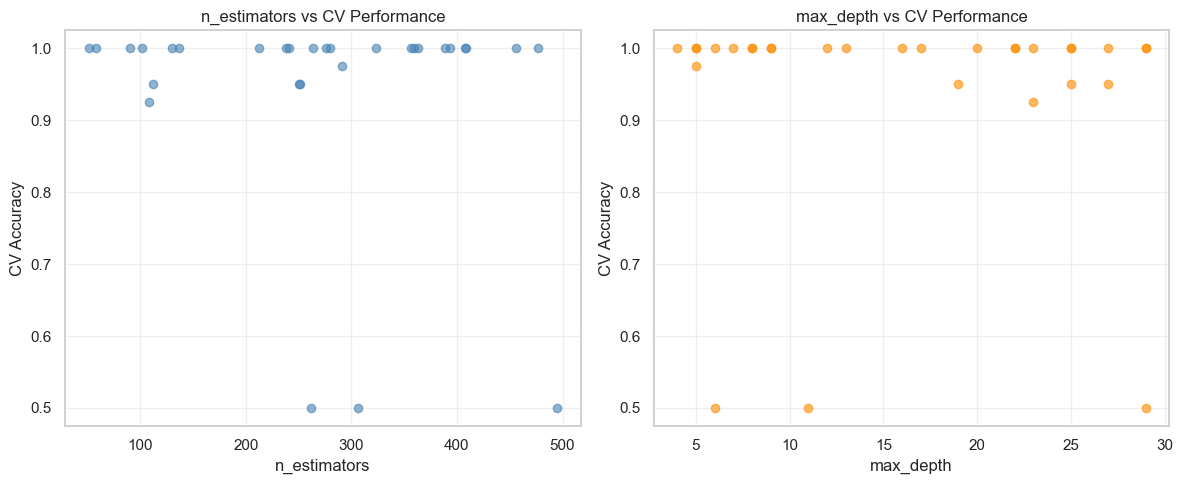

In [22]:
# This visualizes Random Forest randomized search results.
rf_random_results_df = pd.DataFrame(rf_random_search.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(rf_random_results_df['param_n_estimators'], rf_random_results_df['mean_test_score'], alpha=0.6, c='steelblue')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('CV Accuracy')
axes[0].set_title('n_estimators vs CV Performance')
axes[0].grid(True, alpha=0.3)
axes[1].scatter(rf_random_results_df['param_max_depth'], rf_random_results_df['mean_test_score'], alpha=0.6, c='darkorange')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('max_depth vs CV Performance')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Coarse-To-Fine Tuning Strategy

A practical strategy is:

1. run a broad randomized search over a wide range
2. identify the promising region
3. run a smaller GridSearchCV only inside that region
4. evaluate the final tuned model on the test set once

This is usually faster than brute-force exhaustive search over a huge grid.

In [23]:
# This shows a hybrid randomized-search then grid-search workflow.
rf_param_grid_fine = {
    'n_estimators': [150, 200, 250],
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}
rf_grid_fine = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid_fine, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid_fine.fit(X_train, y_train)
rf_grid_fine_pred = rf_grid_fine.best_estimator_.predict(X_test)
print('Fine Grid Best Parameters:', rf_grid_fine.best_params_)
print('Fine Grid Best CV Accuracy:', rf_grid_fine.best_score_)
print('Fine Grid Test Accuracy:', accuracy_score(y_test, rf_grid_fine_pred))

Fine Grid Best Parameters: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 150}
Fine Grid Best CV Accuracy: 1.0
Fine Grid Test Accuracy: 1.0


### RandomizedSearchCV Checklist

- split train and test before tuning
- keep preprocessing inside a pipeline
- set `random_state` so the search is reproducible
- choose `n_iter` based on search-space complexity
- match distributions to parameter meaning, especially `loguniform` for regularization
- use `return_train_score=True` when inspecting overfitting matters
- align the scoring metric with the business objective
- inspect the train/CV gap and the results scatter
- use a hybrid refinement step when precision matters
- evaluate the test set exactly once at the end

## Decision Trees

Decision Trees learn by recursively asking binary questions such as `feature <= threshold`.

Key ideas:

- They partition feature space into rectangular regions.
- They are naturally non-linear.
- They detect interactions automatically through split sequences.
- They do not require feature scaling for the split logic itself.
- They are interpretable because each prediction follows a rule path.
- They overfit aggressively if depth and leaf size are not controlled.

Classification impurity measures:

- Gini impurity
- Entropy
- Information gain

Regression impurity measure:

- Variance reduction, which is equivalent to reducing mean squared error inside child nodes.

In [24]:
# This compares the two common classification split criteria.
tree_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=RANDOM_STATE)
tree_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=RANDOM_STATE)
tree_gini.fit(X_train, y_train)
tree_entropy.fit(X_train, y_train)
criterion_comparison = pd.DataFrame([
    {'criterion': 'gini', 'train_accuracy': tree_gini.score(X_train, y_train), 'test_accuracy': tree_gini.score(X_test, y_test)},
    {'criterion': 'entropy', 'train_accuracy': tree_entropy.score(X_train, y_train), 'test_accuracy': tree_entropy.score(X_test, y_test)}
])
display(criterion_comparison)

,criterion,train_accuracy,test_accuracy
0,gini,1.0,1.0
1,entropy,1.0,1.0


Best params: {'max_depth': 1, 'min_samples_leaf': 1}
Best CV accuracy: 1.0


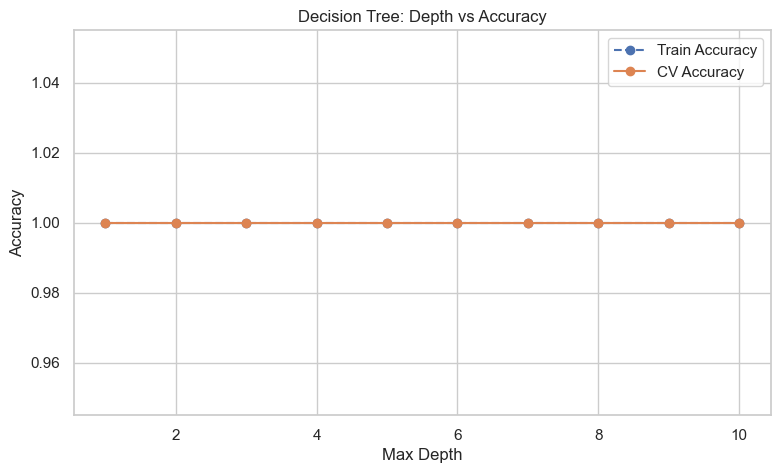

In [25]:
# This tunes decision tree depth with cross-validation and plots the bias-variance pattern.
depth_grid = {'max_depth': range(1, 11), 'min_samples_leaf': [1, 3, 5, 7]}
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), depth_grid, cv=5, scoring='accuracy', return_train_score=True)
tree_grid.fit(X_train, y_train)
depth_only_grid = GridSearchCV(DecisionTreeClassifier(min_samples_leaf=5, random_state=RANDOM_STATE), {'max_depth': range(1, 11)}, cv=5, scoring='accuracy', return_train_score=True)
depth_only_grid.fit(X_train, y_train)
depths = range(1, 11)
train_scores = depth_only_grid.cv_results_['mean_train_score']
cv_scores = depth_only_grid.cv_results_['mean_test_score']
print('Best params:', tree_grid.best_params_)
print('Best CV accuracy:', tree_grid.best_score_)
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, label='Train Accuracy', linestyle='--', marker='o')
plt.plot(depths, cv_scores, label='CV Accuracy', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Depth vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# This fits the tuned decision tree and compares it with the majority baseline.
decision_tree = tree_grid.best_estimator_
decision_tree.fit(X_train, y_train)
tree_train_pred = decision_tree.predict(X_train)
tree_test_pred = decision_tree.predict(X_test)
tree_train_accuracy = accuracy_score(y_train, tree_train_pred)
tree_test_accuracy = accuracy_score(y_test, tree_test_pred)
tree_gap = tree_train_accuracy - tree_test_accuracy
tree_baseline = DummyClassifier(strategy='most_frequent')
tree_baseline.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, tree_baseline.predict(X_test))
tree_cv_scores = cross_val_score(decision_tree, X_train, y_train, cv=5, scoring='accuracy')
print(f'Train Accuracy: {tree_train_accuracy:.3f}')
print(f'Test Accuracy: {tree_test_accuracy:.3f}')
print(f'Train/Test Gap: {tree_gap:.3f}')
print(f'Baseline Accuracy: {baseline_accuracy:.3f}')
print(f'Improvement Over Baseline: {tree_test_accuracy - baseline_accuracy:+.3f}')
print(f'CV Accuracy: {tree_cv_scores.mean():.3f} ± {tree_cv_scores.std():.3f}')
print(classification_report(y_test, tree_test_pred, target_names=['No Flood', 'Flood']))

Train Accuracy: 1.000
Test Accuracy: 1.000
Train/Test Gap: 0.000
Baseline Accuracy: 0.545
Improvement Over Baseline: +0.455
CV Accuracy: 1.000 ± 0.000
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



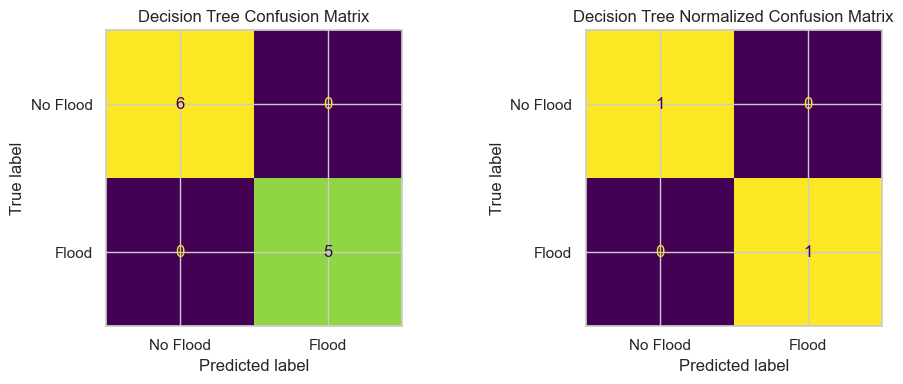

In [27]:
# This inspects the decision tree confusion matrix.
tree_cm = confusion_matrix(y_test, tree_test_pred)
tree_cm_norm = confusion_matrix(y_test, tree_test_pred, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(tree_cm, display_labels=['No Flood', 'Flood']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Decision Tree Confusion Matrix')
ConfusionMatrixDisplay(tree_cm_norm, display_labels=['No Flood', 'Flood']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Decision Tree Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

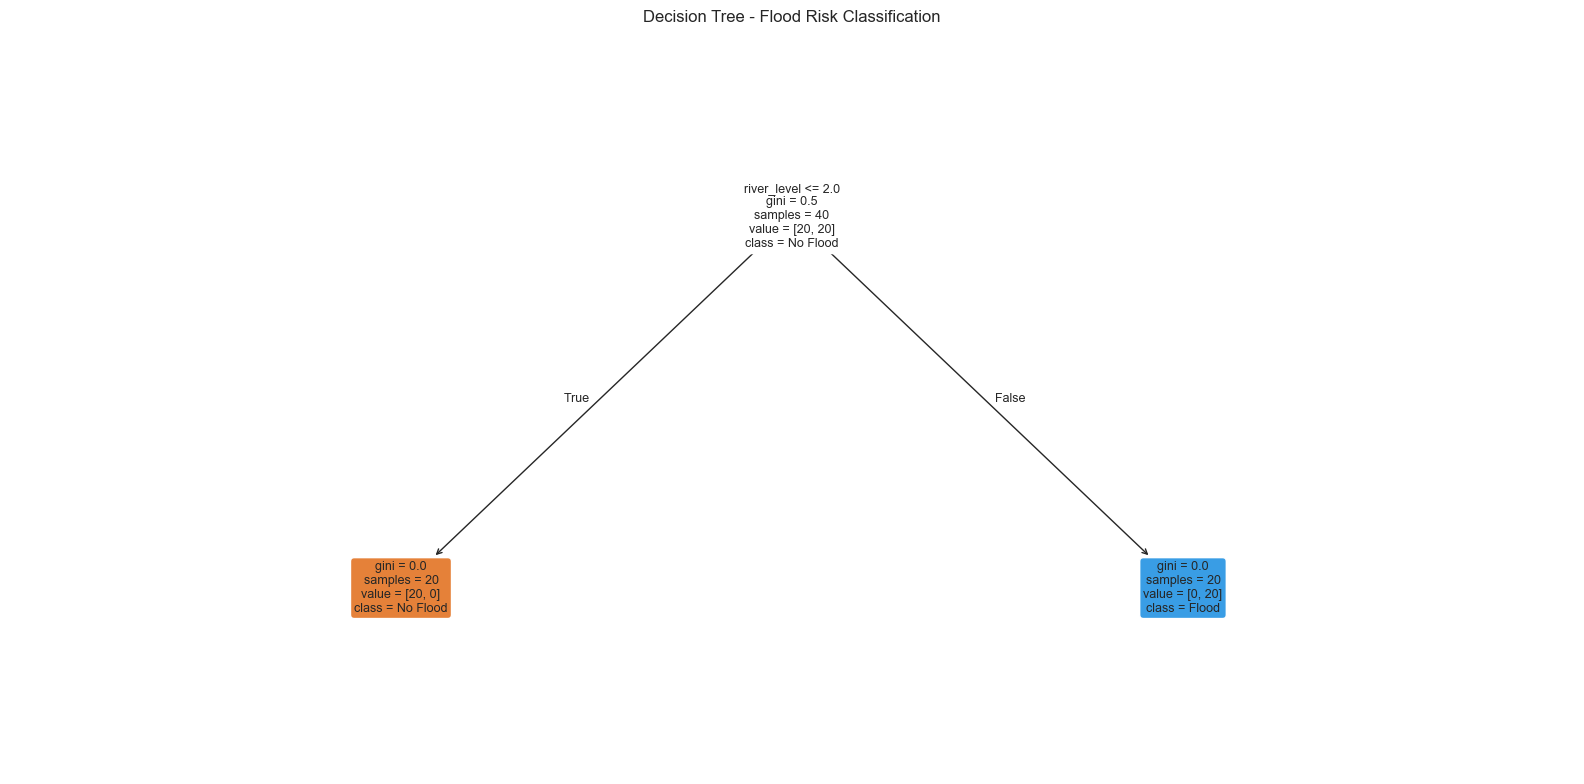

In [28]:
# This visualizes the fitted decision tree as interpretable rules.
plt.figure(figsize=(16, 8))
plot_tree(decision_tree, feature_names=FEATURE_COLUMNS, class_names=['No Flood', 'Flood'], filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree - Flood Risk Classification')
plt.tight_layout()
plt.show()

,feature,importance
3,river_level,1.0
0,rainfall,0.0
1,temperature,0.0
2,humidity,0.0
4,soil_moisture,0.0


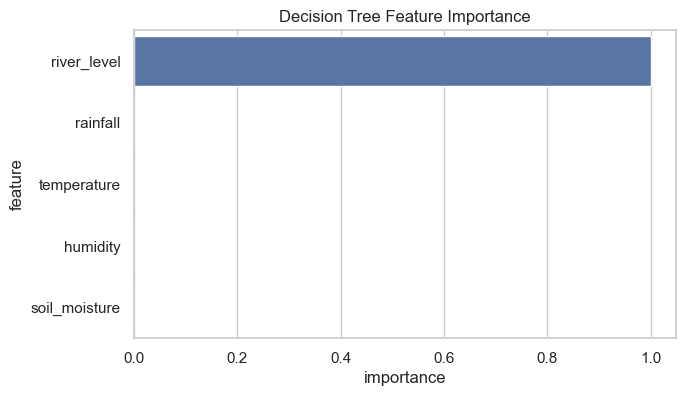

In [29]:
# This shows which features the decision tree relied on most.
tree_importance = pd.DataFrame({'feature': FEATURE_COLUMNS, 'importance': decision_tree.feature_importances_}).sort_values('importance', ascending=False)
display(tree_importance)
plt.figure(figsize=(7, 4))
sns.barplot(data=tree_importance, x='importance', y='feature')
plt.title('Decision Tree Feature Importance')
plt.show()

## Decision Tree Practical Notes

Strengths:

- captures non-linearity naturally
- finds feature interactions automatically
- highly interpretable
- robust to feature scaling issues
- useful for feature engineering discovery

Weaknesses:

- very prone to overfitting
- unstable to small data changes
- axis-aligned splits can be inefficient
- single trees are often weaker than ensembles

Checklist before reporting a decision tree:

- compute train and test accuracy
- inspect the train/test gap
- tune `max_depth` and `min_samples_leaf` with cross-validation
- compare against baseline
- inspect confusion matrix and class report
- review feature importance with domain knowledge
- visualize the final tree and sanity-check the rules

## Evaluation Metrics And Diagnostics

Classification metrics covered across the notebook set:

- accuracy
- precision
- recall
- F1
- macro, micro, and weighted F1
- confusion matrix
- normalized confusion matrix
- TN, FP, FN, TP
- classification report
- ROC curve and ROC-AUC
- precision-recall curve
- probability scores and threshold thinking

In [30]:
# This evaluates the main Random Forest model in detail.
main_model = trained_models['random_forest']
y_train_pred = main_model.predict(X_train_scaled)
y_test_pred = main_model.predict(X_test_scaled)
y_test_proba = main_model.predict_proba(X_test_scaled)[:, 1]
print('Train accuracy:', accuracy_score(y_train, y_train_pred))
print('Test accuracy:', accuracy_score(y_test, y_test_pred))
print('Precision:', precision_score(y_test, y_test_pred, zero_division=0))
print('Recall:', recall_score(y_test, y_test_pred, zero_division=0))
print('F1:', f1_score(y_test, y_test_pred, zero_division=0))
print('F1 macro:', f1_score(y_test, y_test_pred, average='macro', zero_division=0))
print('F1 micro:', f1_score(y_test, y_test_pred, average='micro', zero_division=0))
print('F1 weighted:', f1_score(y_test, y_test_pred, average='weighted', zero_division=0))
print('ROC-AUC:', roc_auc_score(y_test, y_test_proba))
print(classification_report(y_test, y_test_pred, target_names=['No Flood', 'Flood']))

Train accuracy: 1.0
Test accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
F1 macro: 1.0
F1 micro: 1.0
F1 weighted: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



{'TN': np.int64(6), 'FP': np.int64(0), 'FN': np.int64(0), 'TP': np.int64(5)}


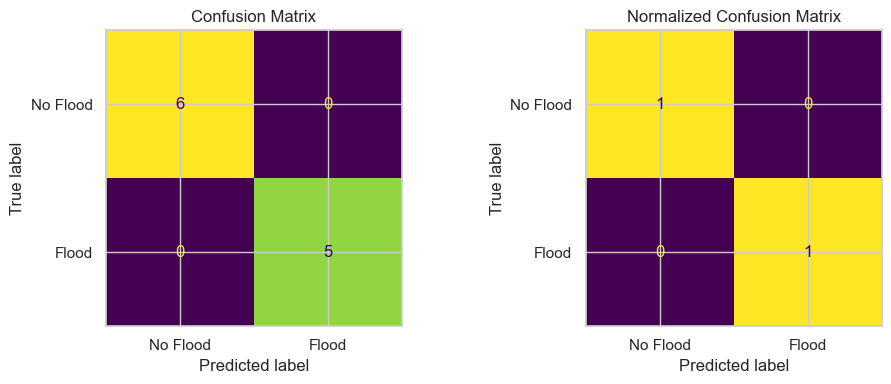

In [31]:
# This shows raw and normalized confusion matrices.
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')
tn, fp, fn, tp = cm.ravel()
print({'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=['No Flood', 'Flood']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')
ConfusionMatrixDisplay(cm_norm, display_labels=['No Flood', 'Flood']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

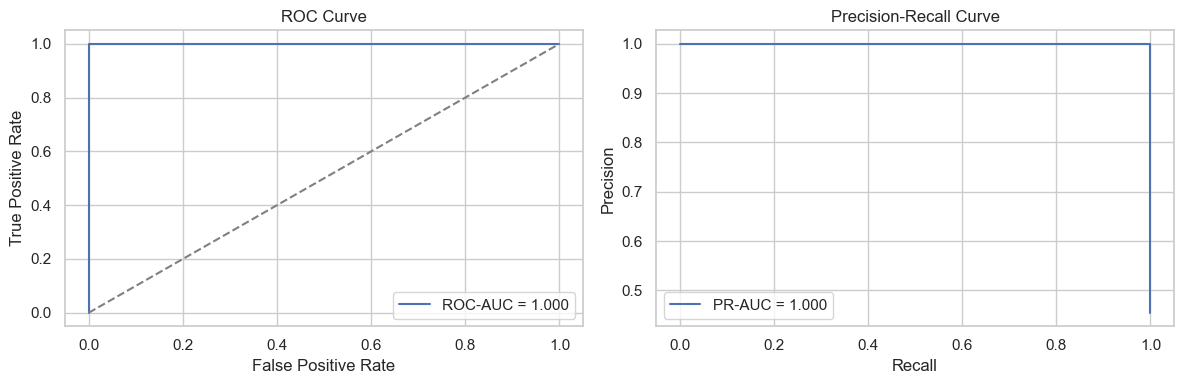

In [32]:
# This plots the ROC curve and precision-recall curve.
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_test_proba):.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[1].plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
plt.tight_layout()
plt.show()

,feature,importance
3,river_level,0.23
0,rainfall,0.22
4,soil_moisture,0.21
1,temperature,0.19
2,humidity,0.15


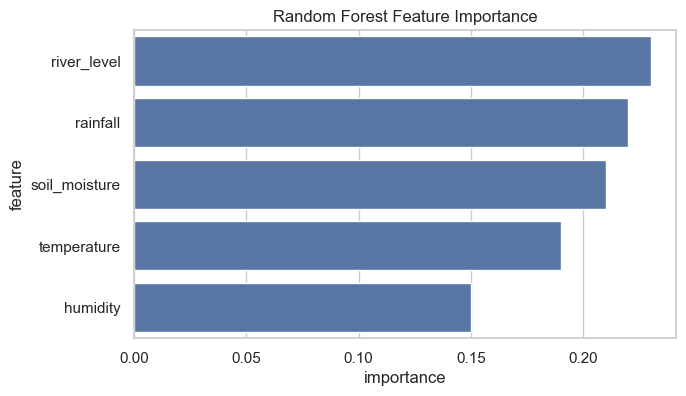

In [33]:
# This extracts and saves Random Forest feature importance values.
feature_importance = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'importance': main_model.feature_importances_
}).sort_values('importance', ascending=False)
feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
display(feature_importance)
plt.figure(figsize=(7, 4))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.show()

## Interpreting Feature Importance From Tree-Based Models

Tree-based models provide built-in feature importance by tracking how much each feature reduced impurity during training.

Important ideas:

- impurity-based importance is also called mean decrease in impurity or MDI
- scores are relative and sum to 1
- high importance means the feature created strong, high-volume splits
- zero importance means the model never used the feature in any split
- importance is not causation
- importance depends on the other features in the model
- correlated features can split or hide each other's importance
- high-cardinality features can look too important with MDI
- permutation importance is slower but more reliable for decisions

Best practice:

- use MDI for quick exploration
- use permutation importance on held-out data before dropping features or presenting conclusions

In [34]:
# This compares single-tree and Random Forest impurity-based feature importance.
tree_importance_df = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': decision_tree.feature_importances_
}).sort_values('Importance', ascending=False)
rf_importance_df = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': main_model.feature_importances_,
    'Std': np.std([estimator.feature_importances_ for estimator in main_model.estimators_], axis=0)
}).sort_values('Importance', ascending=False)
display(tree_importance_df)
display(rf_importance_df)

,Feature,Importance
3,river_level,1.0
0,rainfall,0.0
1,temperature,0.0
2,humidity,0.0
4,soil_moisture,0.0


,Feature,Importance,Std
3,river_level,0.23,0.420833
0,rainfall,0.22,0.414246
4,soil_moisture,0.21,0.407308
1,temperature,0.19,0.392301
2,humidity,0.15,0.357071


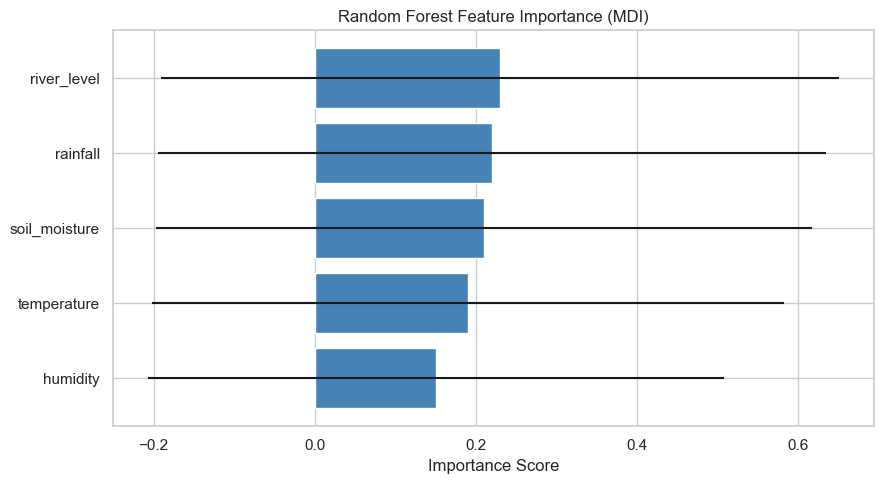

In [35]:
# This visualizes Random Forest impurity-based importance with error bars.
plt.figure(figsize=(9, 5))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], xerr=rf_importance_df['Std'], color='steelblue', edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance (MDI)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Correlation Check Before Interpretation

Before trusting low or zero importance scores, inspect feature correlation. If two predictors are very similar, one can absorb the other's importance.

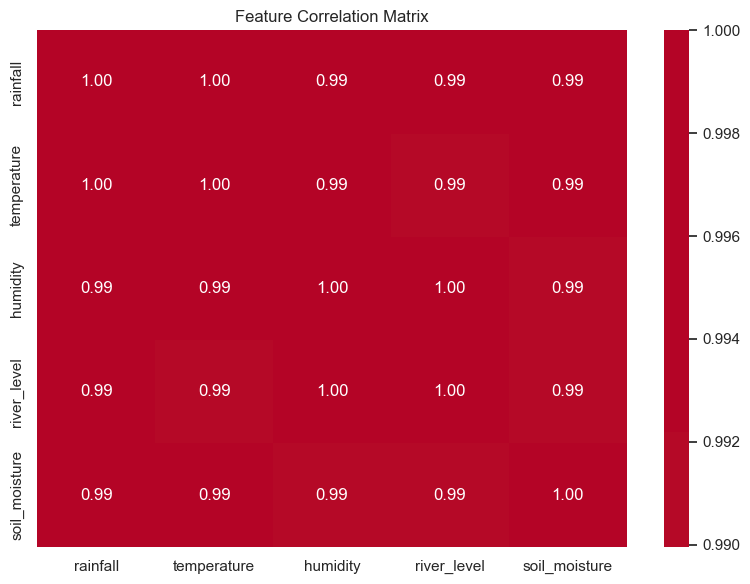

In [36]:
# This plots the feature correlation matrix for interpretation checks.
corr = X_train.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### Permutation Importance

Permutation importance measures how much test-set performance drops when a feature is shuffled. This makes it much better for final interpretation than MDI when correlated or suspicious features exist.

A negative permutation importance means shuffling the feature improved performance, which suggests the feature may be adding noise or helping the model overfit.

In [37]:
# This computes permutation importance on the held-out test set.
perm_result = permutation_importance(main_model, X_test_scaled, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring='accuracy')
perm_importance_df = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values('Importance', ascending=False)
display(perm_importance_df)

,Feature,Importance,Std
0,rainfall,0.0,0.0
1,temperature,0.0,0.0
2,humidity,0.0,0.0
3,river_level,0.0,0.0
4,soil_moisture,0.0,0.0


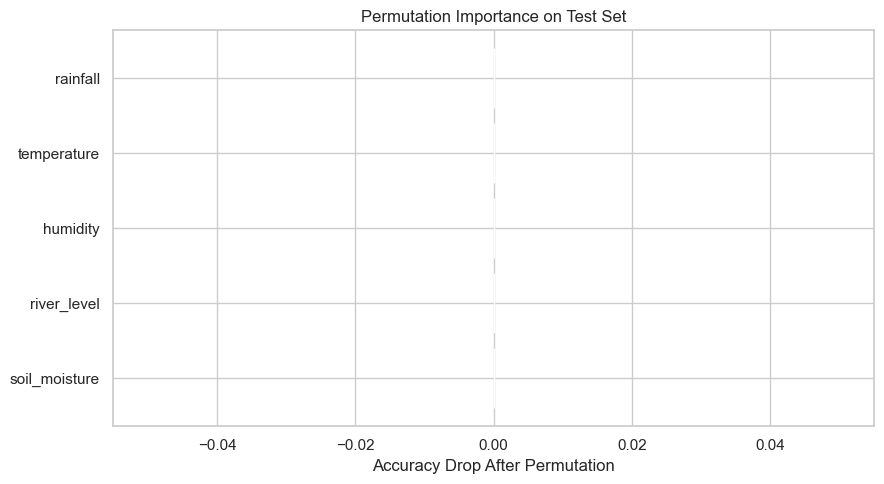

In [38]:
# This visualizes permutation importance from the test set.
plt.figure(figsize=(9, 5))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], xerr=perm_importance_df['Std'], color='darkorange', edgecolor='white')
plt.xlabel('Accuracy Drop After Permutation')
plt.title('Permutation Importance on Test Set')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,Feature,MDI_Importance,Permutation_Importance
0,river_level,0.23,0.0
1,rainfall,0.22,0.0
2,soil_moisture,0.21,0.0
3,temperature,0.19,0.0
4,humidity,0.15,0.0


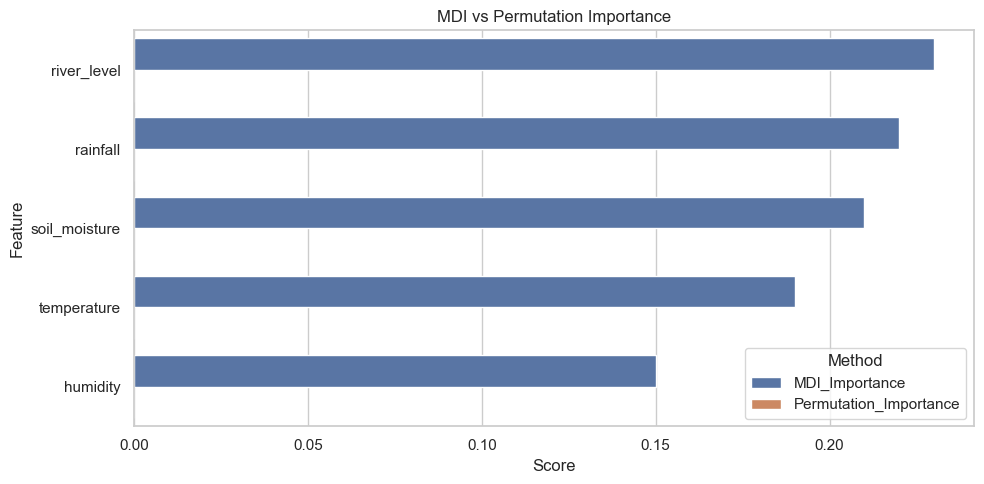

In [39]:
# This compares MDI and permutation importance side by side.
importance_comparison = rf_importance_df[['Feature', 'Importance']].rename(columns={'Importance': 'MDI_Importance'}).merge(
    perm_importance_df[['Feature', 'Importance']].rename(columns={'Importance': 'Permutation_Importance'}),
    on='Feature'
).sort_values('MDI_Importance', ascending=False)
display(importance_comparison)
comparison_plot = importance_comparison.melt(id_vars='Feature', var_name='Method', value_name='Score')
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_plot, x='Score', y='Feature', hue='Method')
plt.title('MDI vs Permutation Importance')
plt.tight_layout()
plt.show()

In [40]:
# This tests whether removing weak features changes model performance.
low_features = perm_importance_df.loc[perm_importance_df['Importance'] <= 0, 'Feature'].tolist()
print('Low or negative permutation-importance features:', low_features)
if low_features:
    kept_features = [feature for feature in FEATURE_COLUMNS if feature not in low_features]
    if kept_features:
        reduced_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
        reduced_model.fit(X_train_scaled[kept_features], y_train)
        reduced_accuracy = accuracy_score(y_test, reduced_model.predict(X_test_scaled[kept_features]))
        print('Original test accuracy:', accuracy_score(y_test, main_model.predict(X_test_scaled)))
        print('Reduced-feature test accuracy:', reduced_accuracy)
        print('Features kept:', kept_features)
    else:
        print('All features were non-positive by permutation importance on this run, so feature-removal retraining is skipped.')
else:
    print('No non-positive permutation-importance features found in this run.')

Low or negative permutation-importance features: ['rainfall', 'temperature', 'humidity', 'river_level', 'soil_moisture']
All features were non-positive by permutation importance on this run, so feature-removal retraining is skipped.


### Interpretation Checklist

Use this checklist before reporting importance:

- confirm the model generalizes well first
- do not treat importance as causation
- inspect the correlation matrix before dropping zero-importance features
- prefer Random Forest importance over a single untuned tree
- compare MDI with permutation importance
- investigate big disagreements between the two methods
- treat high-cardinality features with suspicion
- validate any feature-removal decision by retraining the model
- check whether the ranking makes sense to a domain expert

## Bias, Variance, Overfitting, And Underfitting

Bias-variance ideas covered in the original notebooks:

- underfitting means high bias
- overfitting means high variance
- compare train vs test performance
- inspect learning curves
- small `k` in KNN can overfit
- larger `k` in KNN can smooth too much

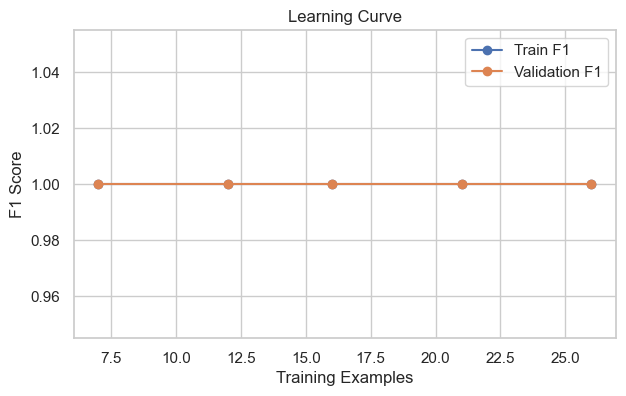

In [41]:
# This plots a learning curve for the main model.
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_scaled,
    y_train,
    cv=3,
    scoring='f1',
    train_sizes=np.linspace(0.3, 1.0, 5)
)
plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train F1')
plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label='Validation F1')
plt.title('Learning Curve')
plt.xlabel('Training Examples')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

## Regression Contrast Demo

The repository also includes regression material to contrast classification with continuous prediction.

This section includes both a linear regression baseline and a decision tree regressor so you can see the difference between smooth models and stepwise tree predictions.

Regression metrics covered:

- MAE
- MSE
- RMSE
- R2
- MAE as a percentage of the mean target

In [42]:
# This compares linear and tree-based regression on river level prediction.
X_reg = clean_data[['rainfall', 'humidity', 'temperature']]
y_reg = clean_data['river_level']
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE)
reg_baseline = DummyRegressor(strategy='mean')
reg_baseline.fit(X_reg_train, y_reg_train)
reg_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
reg_pipeline.fit(X_reg_train, y_reg_train)
tree_reg = DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)
tree_reg.fit(X_reg_train, y_reg_train)
baseline_preds = reg_baseline.predict(X_reg_test)
reg_preds = reg_pipeline.predict(X_reg_test)
tree_reg_preds = tree_reg.predict(X_reg_test)
tree_reg_train_r2 = tree_reg.score(X_reg_train, y_reg_train)
tree_reg_test_r2 = r2_score(y_reg_test, tree_reg_preds)
regression_results = pd.DataFrame([
    {
        'model': 'dummy_regressor',
        'MAE': mean_absolute_error(y_reg_test, baseline_preds),
        'MSE': mean_squared_error(y_reg_test, baseline_preds),
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, baseline_preds)),
        'R2': r2_score(y_reg_test, baseline_preds)
    },
    {
        'model': 'linear_regression',
        'MAE': mean_absolute_error(y_reg_test, reg_preds),
        'MSE': mean_squared_error(y_reg_test, reg_preds),
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, reg_preds)),
        'R2': r2_score(y_reg_test, reg_preds)
    },
    {
        'model': 'decision_tree_regressor',
        'MAE': mean_absolute_error(y_reg_test, tree_reg_preds),
        'MSE': mean_squared_error(y_reg_test, tree_reg_preds),
        'RMSE': np.sqrt(mean_squared_error(y_reg_test, tree_reg_preds)),
        'R2': tree_reg_test_r2
    }
])
regression_results['MAE_pct_of_mean_target'] = regression_results['MAE'] / y_reg_test.mean() * 100
display(regression_results)
print(f'Decision Tree Regressor Train R2: {tree_reg_train_r2:.3f}')
print(f'Decision Tree Regressor Test R2: {tree_reg_test_r2:.3f}')
print(f'Decision Tree Regressor Train/Test Gap: {tree_reg_train_r2 - tree_reg_test_r2:.3f}')

,model,MAE,MSE,RMSE,R2,MAE_pct_of_mean_target
0,dummy_regressor,0.689500,0.588877,0.767383,-0.009751,31.186266
1,linear_regression,0.053267,0.005118,0.071538,0.991225,2.409288
2,decision_tree_regressor,0.142560,0.029073,0.170509,0.950147,6.448005


Decision Tree Regressor Train R2: 0.988
Decision Tree Regressor Test R2: 0.950
Decision Tree Regressor Train/Test Gap: 0.037


## Building a Scikit-Learn Pipeline for Preprocessing and Modeling

As workflows grow, preprocessing becomes as important as modeling. Pipelines bundle transformations and the final estimator into one leakage-safe object.

Why pipelines matter:

- they apply steps in the correct order every time
- they refit preprocessing inside each CV fold, preventing leakage
- they make cross-validation and tuning honest
- they are reproducible and deployment-friendly
- they prevent train/test preprocessing mismatches

Key idea:

- every intermediate step is a transformer with `fit` and `transform`
- the final step is an estimator with `fit` and `predict`
- the full pipeline behaves like a single scikit-learn model

### Why Pipelines Prevent Leakage

If you scale or impute outside the pipeline before cross-validation, the transformer sees the entire training set, including the samples that later become validation folds. That leaks validation-fold statistics into preprocessing and inflates CV scores.

With a pipeline, each fold starts fresh:

- the imputer fits on that fold's training portion only
- the scaler fits on that fold's training portion only
- the encoder fits on that fold's training portion only
- the validation fold is transformed using only statistics learned from the fold's training data

In [43]:
# This compares manual preprocessing with a leakage-safe pipeline.
manual_scaler = StandardScaler()
X_train_manual_scaled = manual_scaler.fit_transform(X_train)
manual_scores = cross_val_score(LogisticRegression(max_iter=1000), X_train_manual_scaled, y_train, cv=5, scoring='accuracy')
simple_pipeline = Pipeline([('scaler', StandardScaler()), ('log_reg', LogisticRegression(max_iter=1000))])
pipeline_scores = cross_val_score(simple_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print('Manual preprocessing CV accuracy:', manual_scores.mean(), '+/-', manual_scores.std())
print('Pipeline CV accuracy:', pipeline_scores.mean(), '+/-', pipeline_scores.std())

Manual preprocessing CV accuracy: 1.0 +/- 0.0
Pipeline CV accuracy: 1.0 +/- 0.0


In [44]:
# This fits a simple pipeline and evaluates it on the holdout set.
simple_pipeline.fit(X_train, y_train)
simple_pipeline_pred = simple_pipeline.predict(X_test)
print(classification_report(y_test, simple_pipeline_pred, target_names=['No Flood', 'Flood']))

              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



### Mixed Data Types with ColumnTransformer

Real data often mixes numerical and categorical inputs. `ColumnTransformer` applies different preprocessing to different column groups and concatenates the outputs.

To demonstrate this in this project, the notebook creates a small mixed-type version of the flood dataset by deriving categorical columns from the numerical measurements and injecting a few missing values.

In [45]:
# This creates a mixed-type demo dataset for pipeline examples.
pipeline_demo = clean_data.copy()
pipeline_demo['rainfall_band'] = pd.cut(pipeline_demo['rainfall'], bins=[0, 30, 45, 100], labels=['low', 'medium', 'high'])
pipeline_demo['moisture_flag'] = np.where(pipeline_demo['soil_moisture'] >= pipeline_demo['soil_moisture'].median(), 'wet', 'dry')
pipeline_demo.loc[pipeline_demo.sample(frac=0.1, random_state=RANDOM_STATE).index, 'temperature'] = np.nan
pipeline_demo.loc[pipeline_demo.sample(frac=0.08, random_state=RANDOM_STATE + 1).index, 'rainfall_band'] = np.nan
num_features_pipe = ['rainfall', 'temperature', 'humidity', 'river_level', 'soil_moisture']
cat_features_pipe = ['rainfall_band', 'moisture_flag']
X_pipe = pipeline_demo[num_features_pipe + cat_features_pipe].copy()
y_pipe = pipeline_demo[TARGET_COLUMN].copy()
X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(X_pipe, y_pipe, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_pipe)
display(X_pipe.head())

,rainfall,temperature,humidity,river_level,soil_moisture,rainfall_band,moisture_flag
0,23.5,18.2,45.0,1.2,0.35,low,dry
1,34.2,22.1,52.0,1.8,0.42,medium,dry
2,45.6,25.3,65.0,2.5,0.48,high,wet
3,28.3,20.5,48.0,1.5,0.38,low,dry
4,52.1,28.1,72.0,3.2,0.55,high,wet


In [46]:
# This builds nested transformers for numeric and categorical columns.
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
full_preprocessor = ColumnTransformer([('num', num_transformer, num_features_pipe), ('cat', cat_transformer, cat_features_pipe)], remainder='drop')
full_pipeline = Pipeline([('preprocessor', full_preprocessor), ('model', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))])
full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [47]:
# This trains the mixed-type pipeline and evaluates it on raw test data.
full_pipeline.fit(X_train_pipe, y_train_pipe)
full_pipeline_pred = full_pipeline.predict(X_test_pipe)
print(classification_report(y_test_pipe, full_pipeline_pred, target_names=['No Flood', 'Flood']))

              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



### Inspecting the Pipeline

Inspecting fitted steps is useful for debugging and for understanding what the preprocessing actually learned.

In [48]:
# This inspects learned preprocessing parameters and output feature names.
fitted_scaler = full_pipeline.named_steps['preprocessor'].named_transformers_['num'].named_steps['scaler']
print('Learned means:', fitted_scaler.mean_)
print('Learned scales:', fitted_scaler.scale_)
feature_names_out = full_pipeline.named_steps['preprocessor'].get_feature_names_out()
print('Output feature names:', feature_names_out)

Learned means: [37.53  22.885 57.535  2.128  0.444]
Learned scales: [12.2697229   4.25723208 11.77245832  0.84710743  0.08499412]
Output feature names: ['num__rainfall' 'num__temperature' 'num__humidity' 'num__river_level'
 'num__soil_moisture' 'cat__rainfall_band_high' 'cat__rainfall_band_low'
 'cat__rainfall_band_medium' 'cat__moisture_flag_dry'
 'cat__moisture_flag_wet']


In [49]:
# This cross-validates the full pipeline without leakage.
pipeline_cv_scores = cross_val_score(full_pipeline, X_train_pipe, y_train_pipe, cv=5, scoring='f1')
print('Pipeline CV F1 scores:', np.round(pipeline_cv_scores, 3))
print('Mean CV F1:', pipeline_cv_scores.mean(), '+/-', pipeline_cv_scores.std())

Pipeline CV F1 scores: [1. 1. 1. 1. 1.]
Mean CV F1: 1.0 +/- 0.0


### Pipelines with GridSearchCV

Any parameter anywhere in the pipeline can be tuned using double-underscore notation such as `model__max_depth` or `preprocessor__num__imputer__strategy`.

In [50]:
# This tunes preprocessing and model settings on the full pipeline.
pipeline_baseline = DummyClassifier(strategy='most_frequent')
pipeline_baseline.fit(X_train_pipe, y_train_pipe)
print('Pipeline baseline accuracy:', accuracy_score(y_test_pipe, pipeline_baseline.predict(X_test_pipe)))
pipeline_param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'model__n_estimators': [50, 100],
    'model__max_depth': [4, 6, 8],
    'model__min_samples_leaf': [1, 3]
}
pipeline_grid = GridSearchCV(full_pipeline, pipeline_param_grid, cv=5, scoring='f1', return_train_score=True, n_jobs=-1)
pipeline_grid.fit(X_train_pipe, y_train_pipe)
pipeline_grid_pred = pipeline_grid.best_estimator_.predict(X_test_pipe)
print('Best pipeline parameters:', pipeline_grid.best_params_)
print('Best pipeline CV F1:', pipeline_grid.best_score_)
print(classification_report(y_test_pipe, pipeline_grid_pred, target_names=['No Flood', 'Flood']))

Pipeline baseline accuracy: 0.5454545454545454


Best pipeline parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__n_estimators': 50, 'preprocessor__num__imputer__strategy': 'mean'}
Best pipeline CV F1: 1.0
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



### Saving and Loading Pipelines

A pipeline is a single deployable artifact. Saving the whole pipeline means deployment receives the exact same preprocessing and model logic used during training.

In [51]:
# This saves and reloads the fitted best pipeline.
pipeline_artifact_path = PROJECT_ROOT / 'models' / 'production_pipeline.pkl'
joblib.dump(pipeline_grid.best_estimator_, pipeline_artifact_path)
loaded_pipeline = joblib.load(pipeline_artifact_path)
loaded_pipeline_pred = loaded_pipeline.predict(X_test_pipe)
print('Saved pipeline path:', pipeline_artifact_path)
print('Reloaded pipeline accuracy:', accuracy_score(y_test_pipe, loaded_pipeline_pred))

Saved pipeline path: /Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/production_pipeline.pkl
Reloaded pipeline accuracy: 1.0


### Pipeline Checklist

- train/test split happens before pipeline fitting
- all preprocessing is inside the pipeline
- `ColumnTransformer` uses explicit column lists
- `handle_unknown='ignore'` is set on the encoder
- `remainder` is explicitly controlled
- CV and tuning run on the full pipeline, not preprocessed arrays
- the full pipeline is saved, not just the final model
- test predictions use raw input data through `pipeline.predict()`

## Understanding and Diagnosing Class Imbalance

Class imbalance means one class is much rarer than another, and the rare class is usually the class that matters most in practice.

Why this matters:

- high accuracy can still mean total failure on the minority class
- most learning algorithms are dominated by majority-class examples
- imbalance is a diagnosis problem before it is a mitigation problem
- business cost determines which metric should matter most

,count
target,
0,1899
1,101


,proportion
target,
0,0.9495
1,0.0505


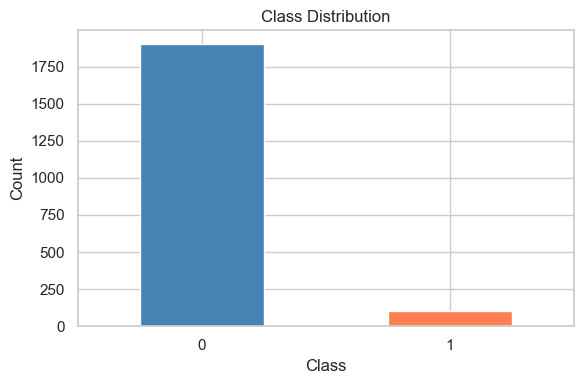

In [52]:
# This creates an imbalanced classification dataset for diagnosis examples.
X_imb, y_imb = make_classification(n_samples=2000, n_features=12, n_informative=5, n_redundant=2, weights=[0.95, 0.05], flip_y=0.01, random_state=RANDOM_STATE)
X_imb = pd.DataFrame(X_imb, columns=[f'feature_{i}' for i in range(X_imb.shape[1])])
y_imb = pd.Series(y_imb, name='target')
display(y_imb.value_counts().rename('count').to_frame())
display(y_imb.value_counts(normalize=True).round(4).rename('proportion').to_frame())
y_imb.value_counts().plot(kind='bar', figsize=(6, 4), color=['steelblue', 'coral'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Why Accuracy Fails

On imbalanced data, a majority-class model can look excellent by accuracy while missing every minority-class event.

In [53]:
# This computes the majority-class baseline on the imbalanced dataset.
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(X_imb, y_imb, test_size=0.2, random_state=RANDOM_STATE, stratify=y_imb)
imb_baseline = DummyClassifier(strategy='most_frequent')
imb_baseline.fit(X_imb_train, y_imb_train)
imb_baseline_pred = imb_baseline.predict(X_imb_test)
print('Baseline Accuracy:', accuracy_score(y_imb_test, imb_baseline_pred))
print(classification_report(y_imb_test, imb_baseline_pred, zero_division=0))

Baseline Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       380
           1       0.00      0.00      0.00        20

    accuracy                           0.95       400
   macro avg       0.47      0.50      0.49       400
weighted avg       0.90      0.95      0.93       400



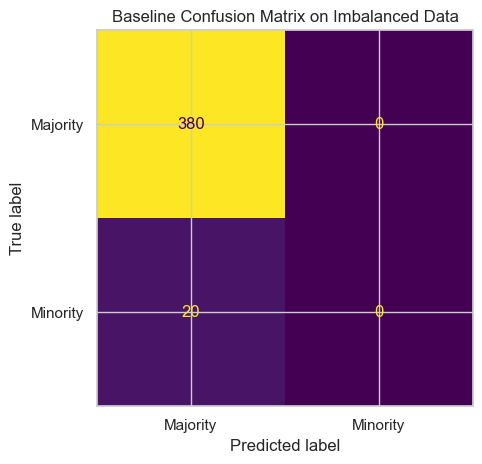

In [54]:
# This shows the baseline confusion matrix that accuracy hides.
imb_cm = confusion_matrix(y_imb_test, imb_baseline_pred)
ConfusionMatrixDisplay(imb_cm, display_labels=['Majority', 'Minority']).plot(colorbar=False)
plt.title('Baseline Confusion Matrix on Imbalanced Data')
plt.tight_layout()
plt.show()

### Stratified Evaluation and Better Metrics

Imbalanced classification requires stratified splitting and minority-sensitive metrics like precision, recall, F1, ROC-AUC, and PR-AUC.

In [55]:
# This trains a standard classifier and reports imbalance-aware metrics.
imb_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000))])
imb_pipeline.fit(X_imb_train, y_imb_train)
imb_pred = imb_pipeline.predict(X_imb_test)
imb_prob = imb_pipeline.predict_proba(X_imb_test)[:, 1]
print(classification_report(y_imb_test, imb_pred, zero_division=0))
print('ROC-AUC:', roc_auc_score(y_imb_test, imb_prob))
print('PR-AUC:', average_precision_score(y_imb_test, imb_prob))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       380
           1       0.00      0.00      0.00        20

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.49       400
weighted avg       0.90      0.94      0.92       400

ROC-AUC: 0.8610526315789473
PR-AUC: 0.22316551849669908


In [56]:
# This uses stratified cross-validation for stable minority-class evaluation.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
imb_cv_scores = cross_val_score(imb_pipeline, X_imb_train, y_imb_train, cv=skf, scoring='f1')
print('Stratified CV F1 scores:', np.round(imb_cv_scores, 3))
print('Mean Stratified CV F1:', imb_cv_scores.mean(), '+/-', imb_cv_scores.std())

Stratified CV F1 scores: [0. 0. 0. 0. 0.]
Mean Stratified CV F1: 0.0 +/- 0.0


### Threshold Effects

The default 0.5 threshold is often too conservative for minority detection. Looking at precision, recall, and F1 across thresholds shows the trade-off explicitly.

In [57]:
# This evaluates the precision-recall trade-off across thresholds.
threshold_rows = []
for t in np.arange(0.1, 0.6, 0.05):
    y_custom = (imb_prob >= t).astype(int)
    threshold_rows.append({
        'threshold': round(float(t), 2),
        'precision': precision_score(y_imb_test, y_custom, zero_division=0),
        'recall': recall_score(y_imb_test, y_custom, zero_division=0),
        'f1': f1_score(y_imb_test, y_custom, zero_division=0)
    })
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,threshold,precision,recall,f1
0,0.10,0.237288,0.70,0.354430
1,0.15,0.205128,0.40,0.271186
2,0.20,0.206897,0.30,0.244898
3,0.25,0.200000,0.20,0.200000
4,0.30,0.230769,0.15,0.181818
5,0.35,0.285714,0.10,0.148148
6,0.40,0.250000,0.05,0.083333
7,0.45,0.000000,0.00,0.000000
8,0.50,0.000000,0.00,0.000000
9,0.55,0.000000,0.00,0.000000


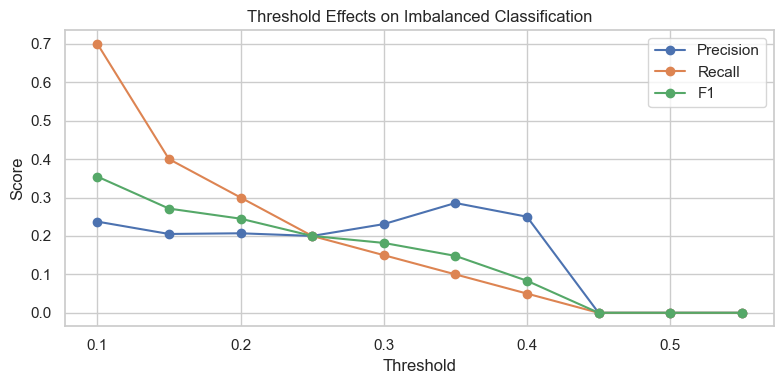

In [58]:
# This plots threshold versus precision, recall, and F1.
plt.figure(figsize=(8, 4))
plt.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Effects on Imbalanced Classification')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Imbalance Diagnosis Checklist

- inspect class counts and proportions before modeling
- compute the majority-class baseline
- use stratified train/test split and stratified CV
- inspect the confusion matrix
- report precision, recall, and F1, not just accuracy
- consider PR-AUC when imbalance is severe
- choose metrics based on business error costs
- diagnose before deciding on resampling or reweighting

## Applying Class Weights to Handle Imbalanced Data

Class weights change the learning objective so that mistakes on minority-class samples cost more than mistakes on majority-class samples.

Why class weights are a strong first intervention:

- they do not modify the dataset
- they are fast to apply
- they are supported by many scikit-learn classifiers
- they directly encode cost-sensitive learning
- they often improve minority recall substantially

Trade-off:

- accuracy may go down
- minority recall often goes up sharply
- false positives usually increase as the model stops ignoring the minority class

In [59]:
# This computes balanced class weights for the imbalanced dataset.
imb_classes = np.unique(y_imb_train)
imb_weights = compute_class_weight(class_weight='balanced', classes=imb_classes, y=y_imb_train)
imb_weight_dict = dict(zip(imb_classes, imb_weights))
print('Balanced class weights:', imb_weight_dict)

Balanced class weights: {np.int64(0): np.float64(0.5266622778143516), np.int64(1): np.float64(9.876543209876543)}


In [60]:
# This compares unweighted and weighted logistic regression on imbalanced data.
model_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_weighted = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
model_base.fit(X_imb_train, y_imb_train)
model_weighted.fit(X_imb_train, y_imb_train)
print('=== Without Class Weights ===')
print(classification_report(y_imb_test, model_base.predict(X_imb_test), zero_division=0))
print('=== With Class Weights (balanced) ===')
print(classification_report(y_imb_test, model_weighted.predict(X_imb_test), zero_division=0))

=== Without Class Weights ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       380
           1       0.00      0.00      0.00        20

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.49       400
weighted avg       0.90      0.94      0.92       400

=== With Class Weights (balanced) ===
              precision    recall  f1-score   support

           0       0.99      0.78      0.88       380
           1       0.17      0.85      0.29        20

    accuracy                           0.79       400
   macro avg       0.58      0.82      0.58       400
weighted avg       0.95      0.79      0.85       400



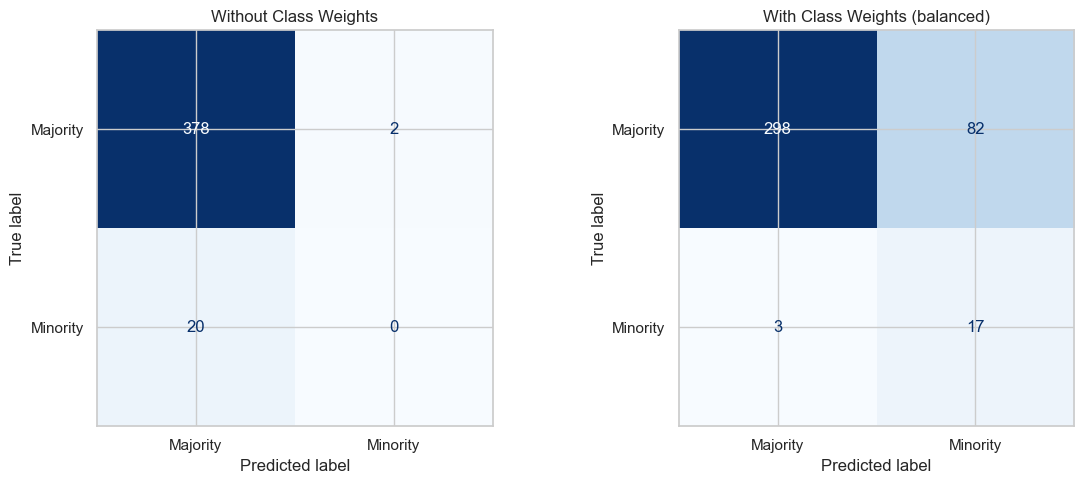

In [61]:
# This shows how class weights change the confusion matrix.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in zip(axes, [model_base, model_weighted], ['Without Class Weights', 'With Class Weights (balanced)']):
    ConfusionMatrixDisplay.from_estimator(model, X_imb_test, y_imb_test, display_labels=['Majority', 'Minority'], cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Threshold Tuning with Class Weights

Class weights shift the predicted probability distribution. Threshold tuning then chooses the operating point on that new distribution. These are complementary levers.

In [62]:
# This evaluates weighted-model precision, recall, and F1 across thresholds.
y_prob_weighted = model_weighted.predict_proba(X_imb_test)[:, 1]
weighted_threshold_rows = []
for t in np.arange(0.1, 0.7, 0.05):
    y_custom = (y_prob_weighted >= t).astype(int)
    weighted_threshold_rows.append({
        'threshold': round(float(t), 2),
        'precision': precision_score(y_imb_test, y_custom, zero_division=0),
        'recall': recall_score(y_imb_test, y_custom, zero_division=0),
        'f1': f1_score(y_imb_test, y_custom, zero_division=0)
    })
weighted_threshold_df = pd.DataFrame(weighted_threshold_rows)
display(weighted_threshold_df)

,threshold,precision,recall,f1
0,0.10,0.087719,1.00,0.161290
1,0.15,0.103627,1.00,0.187793
2,0.20,0.107955,0.95,0.193878
3,0.25,0.117284,0.95,0.208791
4,0.30,0.126667,0.95,0.223529
5,0.35,0.141791,0.95,0.246753
6,0.40,0.152542,0.90,0.260870
7,0.45,0.168224,0.90,0.283465
8,0.50,0.171717,0.85,0.285714
9,0.55,0.182796,0.85,0.300885


In [63]:
# This cross-validates the weighted model with stratification.
weighted_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_recall = cross_val_score(model_weighted, X_imb_train, y_imb_train, cv=weighted_skf, scoring='recall')
cv_precision = cross_val_score(model_weighted, X_imb_train, y_imb_train, cv=weighted_skf, scoring='precision')
cv_f1 = cross_val_score(model_weighted, X_imb_train, y_imb_train, cv=weighted_skf, scoring='f1')
print('CV Recall:', cv_recall.mean(), '+/-', cv_recall.std())
print('CV Precision:', cv_precision.mean(), '+/-', cv_precision.std())
print('CV F1:', cv_f1.mean(), '+/-', cv_f1.std())

CV Recall: 0.8264705882352942 +/- 0.09269956495345895
CV Precision: 0.15536223545304448 +/- 0.01066630866864985
CV F1: 0.2613923698134224 +/- 0.0191320618981131


### Tuning Manual Weight Ratios

If `balanced` is not the right trade-off, search over manual weight ratios and optimize the metric that matches the business goal, often recall or F1.

In [64]:
# This tunes class-weight ratios systematically.
weight_param_grid = {'class_weight': [{0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 15}, {0: 1, 1: 20}, 'balanced']}
weight_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), weight_param_grid, cv=weighted_skf, scoring='recall', n_jobs=-1)
weight_grid.fit(X_imb_train, y_imb_train)
print('Best class_weight:', weight_grid.best_params_)
print('Best CV Recall:', weight_grid.best_score_)

Best class_weight: {'class_weight': {0: 1, 1: 20}}
Best CV Recall: 0.8264705882352942


### Class Weights Checklist

- start with `class_weight='balanced'`
- compare against the unweighted model using recall and F1, not accuracy alone
- inspect the confusion matrix to see FN and FP movement
- use stratified CV when comparing weighted and unweighted models
- tune thresholds on validation data if needed
- search manual weight ratios when business costs are explicit
- remember that class weights amplify signal, they do not create it

## Comparing Model Performance Across Multiple Models

Professional model selection requires comparing multiple candidates under the same conditions. The goal is not just to pick a winner, but to understand what the data structure favors.

Fair comparison requires:

- same train/test split
- same preprocessing pipeline
- same evaluation metric
- same cross-validation folds
- comparable tuning effort
- no repeated test-set selection

In [65]:
# This builds a shared preprocessing pipeline factory for fair model comparison.
comparison_num_features = X_imb_train.columns.tolist()
comparison_preprocessor = ColumnTransformer([('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), comparison_num_features)], remainder='drop')
def make_comparison_pipeline(model):
    return Pipeline([('preprocessor', comparison_preprocessor), ('model', model)])

### Cross-Validation Comparison with Mean and Standard Deviation

Cross-validation gives a stable estimate of performance and a measure of uncertainty. For this imbalanced classification example, F1 is the comparison metric.

In [66]:
# This compares multiple model families on the same folds and metric.
models_compare = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=11)
}
comparison_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison_rows = []
for name, model in models_compare.items():
    pipeline = make_comparison_pipeline(model)
    scores = cross_val_score(pipeline, X_imb_train, y_imb_train, cv=comparison_skf, scoring='f1')
    comparison_rows.append({'Model': name, 'CV Mean F1': round(scores.mean(), 3), 'CV Std F1': round(scores.std(), 3)})
results_df = pd.DataFrame(comparison_rows).sort_values('CV Mean F1', ascending=False)
display(results_df)

,Model,CV Mean F1,CV Std F1
3,Gradient Boosting,0.548,0.134
1,Decision Tree,0.519,0.074
2,Random Forest,0.499,0.115
4,KNN,0.278,0.143
0,Logistic Regression,0.000,0.000


### Train/CV Gap Diagnosis

Comparing train and CV scores reveals whether a model is underfitting, overfitting, or well-fitted.

In [67]:
# This computes train and CV gaps for each model.
gap_rows = []
for name, model in models_compare.items():
    pipeline = make_comparison_pipeline(model)
    cv_result = cross_validate(pipeline, X_imb_train, y_imb_train, cv=comparison_skf, scoring='f1', return_train_score=True)
    train_mean = cv_result['train_score'].mean()
    cv_mean = cv_result['test_score'].mean()
    gap_rows.append({'Model': name, 'Train F1': round(train_mean, 3), 'CV F1': round(cv_mean, 3), 'Gap': round(train_mean - cv_mean, 3)})
gap_df = pd.DataFrame(gap_rows).sort_values('CV F1', ascending=False)
display(gap_df)

,Model,Train F1,CV F1,Gap
3,Gradient Boosting,0.976,0.548,0.428
1,Decision Tree,0.801,0.519,0.281
2,Random Forest,1.000,0.499,0.501
4,KNN,0.328,0.278,0.049
0,Logistic Regression,0.028,0.000,0.028


### Reading Mean and Standard Deviation Together

High mean with low standard deviation is ideal. If score differences are smaller than the fold-to-fold variation, the models are effectively tied and the simpler or faster one is usually preferable.

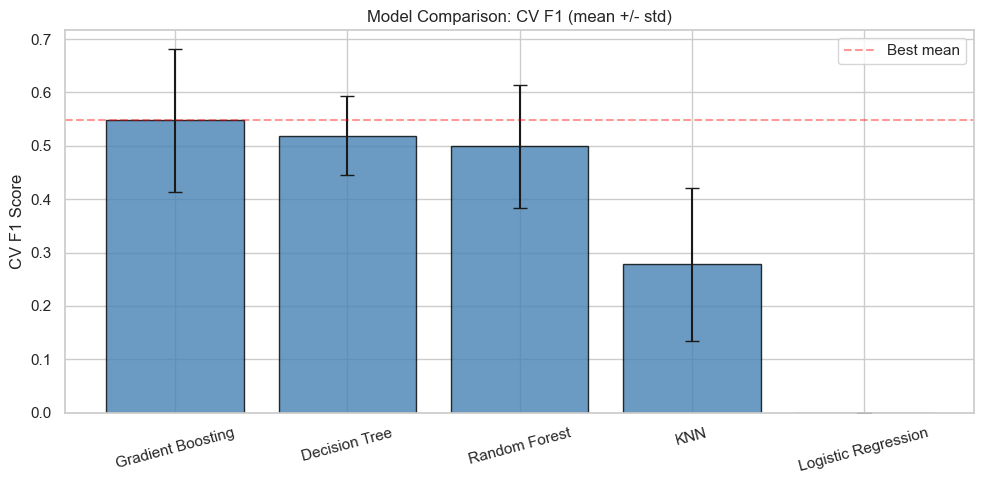

In [68]:
# This visualizes model comparison with error bars.
model_names = results_df['Model'].tolist()
means = results_df['CV Mean F1'].tolist()
stds = results_df['CV Std F1'].tolist()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(model_names, means, yerr=stds, capsize=5, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_ylabel('CV F1 Score')
ax.set_title('Model Comparison: CV F1 (mean +/- std)')
ax.axhline(y=means[0], color='red', linestyle='--', alpha=0.4, label='Best mean')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Comparable Tuning Effort

A tuned complex model should not be compared against an untuned simple model. Each model should receive a similar tuning budget on the same folds.

In [69]:
# This applies the same randomized-search budget to several models.
tuning_configs = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), {'model__C': loguniform(1e-3, 1e2)}),
    'Random Forest': (RandomForestClassifier(random_state=RANDOM_STATE), {'model__n_estimators': randint(50, 300), 'model__max_depth': randint(3, 20)}),
    'KNN': (KNeighborsClassifier(), {'model__n_neighbors': randint(3, 30)})
}
tuned_results = []
for name, (model, param_dist) in tuning_configs.items():
    pipeline = make_comparison_pipeline(model)
    search = RandomizedSearchCV(pipeline, param_dist, n_iter=15, cv=comparison_skf, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)
    search.fit(X_imb_train, y_imb_train)
    tuned_results.append({'Model': name, 'Best CV F1': round(search.best_score_, 3), 'Best Params': search.best_params_})
tuned_results_df = pd.DataFrame(tuned_results).sort_values('Best CV F1', ascending=False)
display(tuned_results_df)

,Model,Best CV F1,Best Params
1,Random Forest,0.506,"{'model__max_depth': 17, 'model__n_estimators'..."
2,KNN,0.337,{'model__n_neighbors': 9}
0,Logistic Regression,0.000,{'model__C': 0.0745934328572655}


### Final Test Set Evaluation

Cross-validation is for model selection. The test set is for honest final reporting, exactly once, after the winner is chosen.

In [70]:
# This selects the best tuned model and evaluates it once on the test set.
best_model_name = tuned_results_df.iloc[0]['Model']
best_model, best_param_dist = tuning_configs[best_model_name]
best_pipeline = make_comparison_pipeline(best_model)
best_search = RandomizedSearchCV(best_pipeline, best_param_dist, n_iter=15, cv=comparison_skf, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)
best_search.fit(X_imb_train, y_imb_train)
best_pred = best_search.best_estimator_.predict(X_imb_test)
best_prob = best_search.best_estimator_.predict_proba(X_imb_test)[:, 1]
print('Selected model:', best_model_name)
print('Final Test F1:', f1_score(y_imb_test, best_pred, zero_division=0))
print(classification_report(y_imb_test, best_pred, zero_division=0))
print('Final Test ROC-AUC:', roc_auc_score(y_imb_test, best_prob))

Selected model: Random Forest
Final Test F1: 0.6206896551724138
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       380
           1       1.00      0.45      0.62        20

    accuracy                           0.97       400
   macro avg       0.99      0.72      0.80       400
weighted avg       0.97      0.97      0.97       400

Final Test ROC-AUC: 0.9318421052631579


### Multi-Metric Comparison

On imbalanced problems, model choice should consider multiple metrics because the best recall model may not be the best precision model.

In [71]:
# This reports recall, precision, F1, and ROC-AUC for several models.
metric_rows = []
for name, model in models_compare.items():
    pipeline = make_comparison_pipeline(model)
    pipeline.fit(X_imb_train, y_imb_train)
    y_pred = pipeline.predict(X_imb_test)
    y_prob = pipeline.predict_proba(X_imb_test)[:, 1] if hasattr(pipeline.named_steps['model'], 'predict_proba') else np.zeros(len(y_imb_test))
    metric_rows.append({'Model': name, 'Recall': round(recall_score(y_imb_test, y_pred, zero_division=0), 3), 'Precision': round(precision_score(y_imb_test, y_pred, zero_division=0), 3), 'F1': round(f1_score(y_imb_test, y_pred, zero_division=0), 3), 'ROC-AUC': round(roc_auc_score(y_imb_test, y_prob), 3)})
metric_results_df = pd.DataFrame(metric_rows).sort_values('F1', ascending=False)
display(metric_results_df)

,Model,Recall,Precision,F1,ROC-AUC
3,Gradient Boosting,0.50,1.000,0.667,0.959
2,Random Forest,0.40,1.000,0.571,0.930
1,Decision Tree,0.45,0.643,0.529,0.823
4,KNN,0.35,1.000,0.519,0.887
0,Logistic Regression,0.00,0.000,0.000,0.861


### Model Comparison Checklist

- use the same train/test split for every model
- keep preprocessing inside a shared pipeline
- choose the metric before training anything
- use stratified CV for classification
- report both CV mean and CV std
- inspect train/CV gaps, not just CV means
- give each model a comparable tuning budget
- use the test set once, only after selection
- document the final selection rationale, including non-score constraints

## Selecting the Final Model Based on Metrics and Use Case

The highest CV score is not automatically the best deployment choice. Final selection must balance performance, stability, business cost, interpretability, and deployment constraints.

Selection dimensions:

- metric aligned with the real objective
- stability across CV folds
- train/CV/test gap behavior
- threshold-adjusted recall and precision
- latency and environment constraints
- interpretability or regulatory requirements

In [72]:
# This assembles candidate models and their comparison metrics.
final_candidates = {name: make_comparison_pipeline(model) for name, model in models_compare.items()}
cv_means = dict(zip(results_df['Model'], results_df['CV Mean F1']))
cv_stds = dict(zip(results_df['Model'], results_df['CV Std F1']))
selection_summary_df = pd.DataFrame({'Model': list(cv_means.keys()), 'CV Mean F1': [cv_means[m] for m in cv_means.keys()], 'CV Std F1': [cv_stds[m] for m in cv_means.keys()]})
display(selection_summary_df.sort_values('CV Mean F1', ascending=False))

,Model,CV Mean F1,CV Std F1
0,Gradient Boosting,0.548,0.134
1,Decision Tree,0.519,0.074
2,Random Forest,0.499,0.115
3,KNN,0.278,0.143
4,Logistic Regression,0.000,0.000


In [73]:
# This estimates CV mean-plus-or-minus-std ranges for selection stability.
range_rows = []
for model_name in cv_means:
    range_rows.append({'Model': model_name, 'Lower': round(cv_means[model_name] - cv_stds[model_name], 3), 'Upper': round(cv_means[model_name] + cv_stds[model_name], 3)})
range_df = pd.DataFrame(range_rows).sort_values('Upper', ascending=False)
display(range_df)

,Model,Lower,Upper
0,Gradient Boosting,0.414,0.682
2,Random Forest,0.384,0.614
1,Decision Tree,0.445,0.593
3,KNN,0.135,0.421
4,Logistic Regression,0.000,0.000


### Test Set Confirmation

After CV-based selection, candidates can be compared on the held-out test set exactly once to confirm generalization.

In [74]:
# This evaluates all final candidates on the held-out test set.
test_rows = []
for name, pipeline in final_candidates.items():
    pipeline.fit(X_imb_train, y_imb_train)
    y_pred = pipeline.predict(X_imb_test)
    y_prob = pipeline.predict_proba(X_imb_test)[:, 1] if hasattr(pipeline.named_steps['model'], 'predict_proba') else np.zeros(len(y_imb_test))
    test_rows.append({'Model': name, 'Test F1': round(f1_score(y_imb_test, y_pred, zero_division=0), 3), 'Recall': round(recall_score(y_imb_test, y_pred, zero_division=0), 3), 'Precision': round(precision_score(y_imb_test, y_pred, zero_division=0), 3), 'PR-AUC': round(average_precision_score(y_imb_test, y_prob), 3)})
test_results_df = pd.DataFrame(test_rows).sort_values('Test F1', ascending=False)
display(test_results_df)

,Model,Test F1,Recall,Precision,PR-AUC
3,Gradient Boosting,0.667,0.50,1.000,0.716
2,Random Forest,0.571,0.40,1.000,0.673
1,Decision Tree,0.529,0.45,0.643,0.495
4,KNN,0.519,0.35,1.000,0.592
0,Logistic Regression,0.000,0.00,0.000,0.223


### Threshold Tuning Before the Final Decision

Probabilistic models should be checked across multiple thresholds because the default 0.5 threshold may not align with the business cost structure.

In [75]:
# This explores thresholds for the current top test-set candidate.
top_model_name = test_results_df.iloc[0]['Model']
top_pipeline = final_candidates[top_model_name]
top_pipeline.fit(X_imb_train, y_imb_train)
top_prob = top_pipeline.predict_proba(X_imb_test)[:, 1]
top_threshold_rows = []
for t in np.arange(0.1, 0.7, 0.05):
    y_custom = (top_prob >= t).astype(int)
    top_threshold_rows.append({'threshold': round(float(t), 2), 'precision': precision_score(y_imb_test, y_custom, zero_division=0), 'recall': recall_score(y_imb_test, y_custom, zero_division=0), 'f1': f1_score(y_imb_test, y_custom, zero_division=0)})
top_threshold_df = pd.DataFrame(top_threshold_rows)
print('Top candidate:', top_model_name)
display(top_threshold_df)

Top candidate: Gradient Boosting


,threshold,precision,recall,f1
0,0.10,0.500000,0.7,0.583333
1,0.15,0.600000,0.6,0.600000
2,0.20,0.625000,0.5,0.555556
3,0.25,0.666667,0.5,0.571429
4,0.30,0.714286,0.5,0.588235
5,0.35,0.714286,0.5,0.588235
6,0.40,0.833333,0.5,0.625000
7,0.45,0.909091,0.5,0.645161
8,0.50,1.000000,0.5,0.666667
9,0.55,1.000000,0.5,0.666667


In [76]:
# This builds a multi-criteria decision table including operational constraints.
constraint_defaults = {'Logistic Regression': {'Latency': '<1ms', 'Interpretable': 'Yes'}, 'Decision Tree': {'Latency': '1-5ms', 'Interpretable': 'Yes'}, 'Random Forest': {'Latency': '5-10ms', 'Interpretable': 'No'}, 'Gradient Boosting': {'Latency': '10-35ms', 'Interpretable': 'No'}, 'KNN': {'Latency': '50ms+', 'Interpretable': 'Low'}}
decision_table_rows = []
for _, row in test_results_df.iterrows():
    model_name = row['Model']
    decision_table_rows.append({'Model': model_name, 'CV Mean F1': cv_means[model_name], 'CV Std F1': cv_stds[model_name], 'Test F1': row['Test F1'], 'Recall': row['Recall'], 'Precision': row['Precision'], 'PR-AUC': row['PR-AUC'], 'Latency': constraint_defaults[model_name]['Latency'], 'Interpretable': constraint_defaults[model_name]['Interpretable']})
decision_table_df = pd.DataFrame(decision_table_rows)
display(decision_table_df)

,Model,CV Mean F1,CV Std F1,Test F1,Recall,Precision,PR-AUC,Latency,Interpretable
0,Gradient Boosting,0.548,0.134,0.667,0.50,1.000,0.716,10-35ms,No
1,Random Forest,0.499,0.115,0.571,0.40,1.000,0.673,5-10ms,No
2,Decision Tree,0.519,0.074,0.529,0.45,0.643,0.495,1-5ms,Yes
3,KNN,0.278,0.143,0.519,0.35,1.000,0.592,50ms+,Low
4,Logistic Regression,0.000,0.000,0.000,0.00,0.000,0.223,<1ms,Yes


### Final Selection Checklist

- choose the metric before training and align it with business cost
- inspect CV mean and CV std together
- inspect train-CV gaps to understand fit quality
- evaluate the test set once, only after candidate selection
- consider threshold tuning before finalizing the deployment choice
- include practical constraints such as latency and interpretability
- prefer the simpler model when differences are within the noise
- document the final rationale, not just the winning score

## Applying Oversampling Techniques to Balance Classes

Oversampling changes what the model sees during training by increasing minority-class representation. Unlike class weights, it leaves the loss function unchanged and instead rebalances the training data itself.

Main approaches:

- random oversampling duplicates minority samples
- SMOTE generates synthetic minority samples between real minority neighbors

Key rule:

- never oversample before the train/test split
- never oversample outside cross-validation
- in production, use `imblearn.pipeline.Pipeline` so oversampling happens only inside each training fold
- in this notebook, lightweight helper functions reproduce the same safe ideas without adding a hard runtime dependency

In [77]:
# This defines simple oversampling helpers and applies random oversampling.
def random_oversample(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_sr = pd.Series(y).reset_index(drop=True)
    class_counts = y_sr.value_counts()
    target_count = class_counts.max()
    X_parts = []
    y_parts = []
    for cls in sorted(class_counts.index):
        idx = y_sr[y_sr == cls].index.to_numpy()
        sampled_idx = rng.choice(idx, size=target_count, replace=True)
        X_parts.append(X_df.iloc[sampled_idx])
        y_parts.append(pd.Series([cls] * target_count))
    X_res = pd.concat(X_parts, ignore_index=True)
    y_res = pd.concat(y_parts, ignore_index=True)
    return X_res, y_res

def simple_smote(X, y, k_neighbors=5, random_state=42):
    rng = np.random.default_rng(random_state)
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_sr = pd.Series(y).reset_index(drop=True)
    class_counts = y_sr.value_counts()
    minority_class = class_counts.idxmin()
    majority_count = class_counts.max()
    X_min = X_df[y_sr == minority_class].reset_index(drop=True)
    n_minority = len(X_min)
    if n_minority < 2:
        return X_df.copy(), y_sr.copy()
    n_neighbors = min(k_neighbors + 1, n_minority)
    nn = NearestNeighbors(n_neighbors=n_neighbors)
    nn.fit(X_min)
    neighbor_idx = nn.kneighbors(X_min, return_distance=False)[:, 1:]
    needed = majority_count - n_minority
    synthetic_rows = []
    for _ in range(needed):
        base_i = rng.integers(0, n_minority)
        neigh_i = rng.choice(neighbor_idx[base_i])
        lam = rng.random()
        base = X_min.iloc[base_i].to_numpy(dtype=float)
        neigh = X_min.iloc[neigh_i].to_numpy(dtype=float)
        synthetic_rows.append(base + lam * (neigh - base))
    X_syn = pd.DataFrame(synthetic_rows, columns=X_df.columns)
    y_syn = pd.Series([minority_class] * len(X_syn))
    X_res = pd.concat([X_df, X_syn], ignore_index=True)
    y_res = pd.concat([y_sr, y_syn], ignore_index=True)
    return X_res, y_res

X_ros, y_ros = random_oversample(X_imb_train, y_imb_train, random_state=RANDOM_STATE)
display(y_ros.value_counts().rename('count_after_random_oversampling').to_frame())

,count_after_random_oversampling
0,1519
1,1519


In [78]:
# This applies a lightweight SMOTE-style interpolation to the training data.
X_smote, y_smote = simple_smote(X_imb_train, y_imb_train, k_neighbors=5, random_state=RANDOM_STATE)
display(y_smote.value_counts().rename('count_after_smote').to_frame())

,count_after_smote
0,1519
1,1519


### Before and After Oversampling

This compares the original unweighted model with a model trained after SMOTE. The expected pattern is lower accuracy but much higher minority recall and a better minority F1.

In [79]:
# This compares unweighted logistic regression with SMOTE-trained logistic regression.
model_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_smote.fit(X_smote, y_smote)
print('=== Without Oversampling ===')
print(classification_report(y_imb_test, model_base.predict(X_imb_test), zero_division=0))
print('=== With SMOTE ===')
print(classification_report(y_imb_test, model_smote.predict(X_imb_test), zero_division=0))

=== Without Oversampling ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       380
           1       0.00      0.00      0.00        20

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.49       400
weighted avg       0.90      0.94      0.92       400

=== With SMOTE ===
              precision    recall  f1-score   support

           0       0.99      0.79      0.88       380
           1       0.18      0.85      0.30        20

    accuracy                           0.80       400
   macro avg       0.58      0.82      0.59       400
weighted avg       0.95      0.80      0.85       400



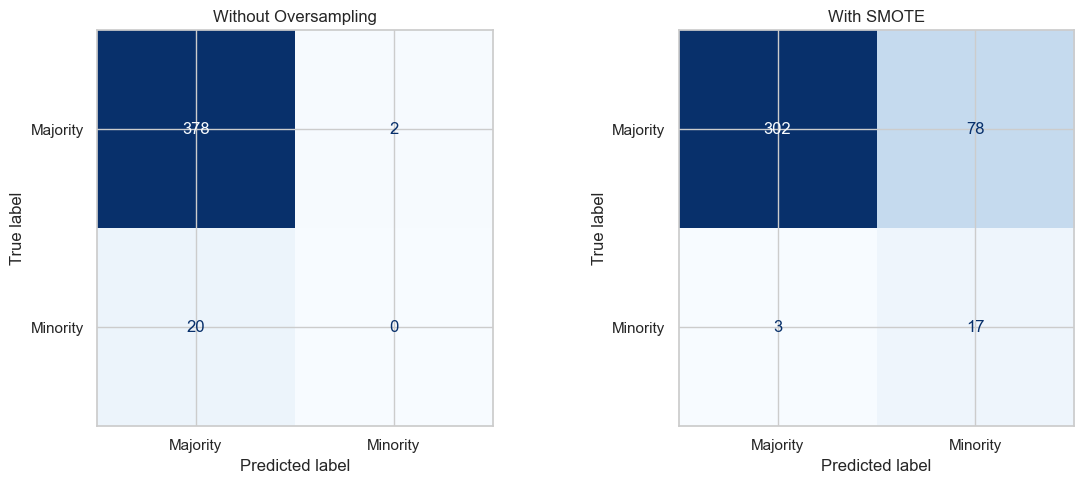

In [80]:
# This shows how oversampling changes the confusion matrix.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in zip(axes, [model_base, model_smote], ['Without Oversampling', 'With SMOTE']):
    ConfusionMatrixDisplay.from_estimator(model, X_imb_test, y_imb_test, display_labels=['Majority', 'Minority'], cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Leakage-Safe Cross-Validation with Fold-Wise Oversampling

Oversampling must happen inside each training fold, never before the split. In production you would typically use `imblearn.pipeline.Pipeline`; here the notebook demonstrates the same idea with an explicit fold-wise helper so the execution stays self-contained.

In [81]:
# This cross-validates SMOTE-like oversampling without leakage.
def foldwise_smote_cv_f1(X, y, splitter, random_state=42):
    scores = []
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_sr = pd.Series(y).reset_index(drop=True)
    for fold_idx, (train_idx, valid_idx) in enumerate(splitter.split(X_df, y_sr)):
        X_fold_train = X_df.iloc[train_idx].reset_index(drop=True)
        y_fold_train = y_sr.iloc[train_idx].reset_index(drop=True)
        X_fold_valid = X_df.iloc[valid_idx].reset_index(drop=True)
        y_fold_valid = y_sr.iloc[valid_idx].reset_index(drop=True)
        X_fold_smote, y_fold_smote = simple_smote(X_fold_train, y_fold_train, random_state=random_state + fold_idx)
        fold_model = LogisticRegression(max_iter=1000, random_state=random_state)
        fold_model.fit(X_fold_smote, y_fold_smote)
        fold_pred = fold_model.predict(X_fold_valid)
        scores.append(f1_score(y_fold_valid, fold_pred, zero_division=0))
    return np.array(scores)

smote_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
smote_cv_scores = foldwise_smote_cv_f1(X_imb_train, y_imb_train, smote_skf, random_state=RANDOM_STATE)
print('SMOTE pipeline CV F1:', smote_cv_scores.mean(), '+/-', smote_cv_scores.std())

SMOTE pipeline CV F1: 0.2591964346286887 +/- 0.03058951719150786


### Comparing Class Weights and Oversampling

The right choice depends on the dataset. A safe workflow is to compare class weights and oversampling on the same stratified CV setup using the same metric.

In [82]:
# This compares unweighted, class-weighted, and fold-wise SMOTE evaluation on the same CV setup.
compare_models = {
    'unweighted': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'class_weight_balanced': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
}
compare_rows = []
for name, model in compare_models.items():
    scores = cross_val_score(model, X_imb_train, y_imb_train, cv=smote_skf, scoring='f1')
    compare_rows.append({'model': name, 'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()})
compare_rows.append({'model': 'foldwise_smote', 'cv_f1_mean': smote_cv_scores.mean(), 'cv_f1_std': smote_cv_scores.std()})
compare_df = pd.DataFrame(compare_rows).sort_values('cv_f1_mean', ascending=False)
display(compare_df)

,model,cv_f1_mean,cv_f1_std
1,class_weight_balanced,0.261392,0.019132
2,foldwise_smote,0.259196,0.030590
0,unweighted,0.000000,0.000000


### Oversampling Checklist

- split train and test before any oversampling
- never resample the test set
- use fold-wise oversampling logic in cross-validation, and in production prefer `imblearn.pipeline.Pipeline` when the environment supports it
- compare against class weights on the same stratified CV setup
- evaluate with recall, F1, PR-AUC, and confusion matrix, not accuracy alone
- prefer SMOTE over random oversampling for numeric clustered minority classes
- avoid aggressive oversampling when the minority class is extremely tiny or noisy

## Applying Pipelines to Prevent Data Leakage

Data leakage happens when information from outside the legitimate training data influences training or evaluation. It usually makes metrics look better than they deserve to be.

Two major types:

- target leakage: features contain information created after the outcome
- train-test leakage: preprocessing is fitted on data that includes validation or test samples

Leakage is dangerous because it does not crash code or raise warnings. It simply creates overconfident metrics that fail in production.

### Target Leakage Example

A post-event feature can make a model look perfect in development even though that feature would not exist at prediction time.

In [83]:
# This demonstrates target leakage with an intentionally invalid feature.
leak_demo = clean_data[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
leak_demo['post_event_flag'] = leak_demo[TARGET_COLUMN]
X_leak_safe = leak_demo[FEATURE_COLUMNS]
X_leak_bad = leak_demo[FEATURE_COLUMNS + ['post_event_flag']]
y_leak = leak_demo[TARGET_COLUMN]
X_leak_train_safe, X_leak_test_safe, y_leak_train, y_leak_test = train_test_split(X_leak_safe, y_leak, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_leak)
X_leak_train_bad, X_leak_test_bad, _, _ = train_test_split(X_leak_bad, y_leak, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_leak)
safe_model = LogisticRegression(max_iter=1000)
bad_model = LogisticRegression(max_iter=1000)
safe_model.fit(X_leak_train_safe, y_leak_train)
bad_model.fit(X_leak_train_bad, y_leak_train)
print('Safe-feature test accuracy:', accuracy_score(y_leak_test, safe_model.predict(X_leak_test_safe)))
print('Leaky-feature test accuracy:', accuracy_score(y_leak_test, bad_model.predict(X_leak_test_bad)))

Safe-feature test accuracy: 1.0
Leaky-feature test accuracy: 1.0


### Why Train/Test Split Alone Is Not Enough

Even if the train/test split is correct, preprocessing can still leak at the cross-validation level if it is fitted before CV begins.

In [84]:
# This demonstrates feature-selection leakage before cross-validation.
X_synth, y_synth = make_classification(n_samples=400, n_features=60, n_informative=5, n_redundant=5, n_repeated=0, n_classes=2, random_state=RANDOM_STATE)
selector_leaky = SelectKBest(score_func=f_classif, k=10)
X_synth_selected = selector_leaky.fit_transform(X_synth, y_synth)
leaky_cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X_synth_selected, y_synth, cv=5, scoring='accuracy')
safe_selector_pipeline = Pipeline([('selector', SelectKBest(score_func=f_classif, k=10)), ('model', LogisticRegression(max_iter=1000))])
safe_cv_scores = cross_val_score(safe_selector_pipeline, X_synth, y_synth, cv=5, scoring='accuracy')
print('Leaky feature-selection CV accuracy:', leaky_cv_scores.mean(), '+/-', leaky_cv_scores.std())
print('Pipeline-safe CV accuracy:', safe_cv_scores.mean(), '+/-', safe_cv_scores.std())

Leaky feature-selection CV accuracy: 0.7675000000000001 +/- 0.02179449471770337
Pipeline-safe CV accuracy: 0.7550000000000001 +/- 0.012747548783981951


### Common Leakage Scenarios and Fixes

Common sources of leakage:

- scaling before split or before cross-validation
- imputation before cross-validation
- one-hot encoding fitted before cross-validation
- feature selection before split or before CV
- target encoding fitted using all labels
- SMOTE or other resampling applied before cross-validation
- preprocessing before GridSearchCV instead of tuning the full pipeline

Correct fix:

- put every data-dependent preprocessing step inside the pipeline
- cross-validate and tune the full pipeline object
- evaluate the test set exactly once after all tuning decisions are finished

### Detecting Suspected Leakage

Warning signs:

- test accuracy much higher than cross-validation
- production performance far below development metrics
- suspiciously predictive features that should not matter
- extreme performance jumps after adding a preprocessing step
- feature importance dominated by post-event or proxy variables

In [85]:
# This compares train, cross-validation, and test performance for a safe pipeline.
leak_check_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
leak_check_pipeline.fit(X_train, y_train)
train_score = leak_check_pipeline.score(X_train, y_train)
test_score = leak_check_pipeline.score(X_test, y_test)
cv_score = cross_val_score(leak_check_pipeline, X_train, y_train, cv=5, scoring='accuracy').mean()
print(f'Train Score: {train_score:.3f}')
print(f'CV Score: {cv_score:.3f}')
print(f'Test Score: {test_score:.3f}')

Train Score: 1.000
CV Score: 1.000
Test Score: 1.000


### Professional Leakage-Safe Workflow

Recommended sequence:

1. split train and test before fitting anything
2. put all preprocessing inside a pipeline
3. cross-validate the pipeline on training data only
4. tune the full pipeline with GridSearchCV or RandomizedSearchCV
5. evaluate the test set once, at the end
6. save the full pipeline, not just the final estimator

In [86]:
# This runs a professional leakage-safe evaluation workflow.
leak_safe_pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
leak_safe_cv_scores = cross_val_score(leak_safe_pipeline, X_train, y_train, cv=5, scoring='f1')
leak_safe_grid = GridSearchCV(leak_safe_pipeline, {'model__C': [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring='f1', n_jobs=-1)
leak_safe_grid.fit(X_train, y_train)
leak_safe_pred = leak_safe_grid.best_estimator_.predict(X_test)
print('CV F1:', leak_safe_cv_scores.mean(), '+/-', leak_safe_cv_scores.std())
print('Best parameters:', leak_safe_grid.best_params_)
print(classification_report(y_test, leak_safe_pred, target_names=['No Flood', 'Flood']))

CV F1: 1.0 +/- 0.0
Best parameters: {'model__C': 0.01}
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



### Leakage Prevention Checklist

- split train and test before any transformation
- fit no preprocessing step on the full dataset
- keep scaling, imputation, encoding, feature selection, and resampling inside the pipeline
- cross-validate the full pipeline, not preprocessed arrays
- tune the full pipeline, not the isolated model
- evaluate the test set exactly once
- save the full pipeline for deployment
- investigate any suspiciously strong metrics before trusting them

## Saving Trained Models Using Pickle

Model serialization converts a trained Python object into a byte stream that can be written to disk and reconstructed later without retraining.

Why saving matters:

- training is expensive and should not be repeated for every prediction
- deployment needs a reusable artifact, not a retraining script
- versioning and rollback require saved model files
- full pipelines preserve preprocessing and model behavior together

This section covers both `pickle` and `joblib`, verification after loading, version metadata, and safe loading practices.

In [87]:
# This saves and reloads a simple trained model using pickle.
import pickle
simple_pickle_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
simple_pickle_model.fit(X_imb_train, y_imb_train)
simple_pickle_path = PROJECT_ROOT / 'models' / 'logistic_model.pkl'
with open(simple_pickle_path, 'wb') as file:
    pickle.dump(simple_pickle_model, file)
with open(simple_pickle_path, 'rb') as file:
    loaded_simple_pickle_model = pickle.load(file)
print('Saved model to', simple_pickle_path)
print(classification_report(y_imb_test, loaded_simple_pickle_model.predict(X_imb_test), zero_division=0))

Saved model to /Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/logistic_model.pkl
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       380
           1       0.00      0.00      0.00        20

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.49       400
weighted avg       0.90      0.94      0.92       400



### Save the Full Pipeline, Not Just the Final Estimator

If a model was trained on scaled, encoded, or imputed features, saving only the final estimator is unsafe. Deployment needs the full preprocessing pipeline and the model together.

In [88]:
# This saves the trained model with joblib and writes an evaluation report.
joblib.dump(main_model, MODEL_PATH)
with open(REPORT_PATH, 'w') as report_file:
    report_file.write('FLOOD PREDICTION MODEL - EVALUATION REPORT\n')
    report_file.write('=' * 50 + '\n\n')
    report_file.write(f'accuracy: {accuracy_score(y_test, y_test_pred):.4f}\n')
    report_file.write(f'precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}\n')
    report_file.write(f'recall: {recall_score(y_test, y_test_pred, zero_division=0):.4f}\n')
    report_file.write(f'f1: {f1_score(y_test, y_test_pred, zero_division=0):.4f}\n')
print(MODEL_PATH)
print(SCALER_PATH)
print(REPORT_PATH)

/Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/flood_prediction_model.pkl
/Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/scaler.pkl
/Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/reports/evaluation_report.txt


In [89]:
# This saves and reloads a full trained pipeline using pickle.
full_pickle_path = PROJECT_ROOT / 'models' / 'churn_pipeline.pkl'
with open(full_pickle_path, 'wb') as file:
    pickle.dump(pipeline_grid.best_estimator_, file)
with open(full_pickle_path, 'rb') as file:
    loaded_full_pipeline = pickle.load(file)
full_pickle_pred = loaded_full_pipeline.predict(X_test_pipe)
print('Saved full pipeline to', full_pickle_path)
print(classification_report(y_test_pipe, full_pickle_pred, target_names=['No Flood', 'Flood']))

Saved full pipeline to /Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/churn_pipeline.pkl
              precision    recall  f1-score   support

    No Flood       1.00      1.00      1.00         6
       Flood       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [90]:
# This verifies model integrity after loading.
sample_pred = loaded_full_pipeline.predict(X_test_pipe[:5])
loaded_f1 = f1_score(y_test_pipe, loaded_full_pipeline.predict(X_test_pipe), zero_division=0)
original_f1 = f1_score(y_test_pipe, pipeline_grid.best_estimator_.predict(X_test_pipe), zero_division=0)
print('Sample predictions:', sample_pred)
print('Loaded pipeline Test F1:', loaded_f1)
print('Original pipeline Test F1:', original_f1)
print('Match:', np.isclose(loaded_f1, original_f1))

Sample predictions: [0 0 0 0 0]
Loaded pipeline Test F1: 1.0
Original pipeline Test F1: 1.0
Match: True


### Version Compatibility and Security

Pickle and joblib files are not guaranteed to load across different Python, scikit-learn, or NumPy versions. Also, pickle loading executes instructions stored in the file, so untrusted `.pkl` files must never be loaded.

In [91]:
# This writes environment metadata alongside the serialized pipeline.
import json
import sklearn
import sys
serialization_metadata = {
    'python_version': sys.version,
    'sklearn_version': sklearn.__version__,
    'numpy_version': np.__version__,
    'trained_on': '2026-05-19',
    'model_description': 'Flood risk pipeline notebook serialization demo'
}
metadata_path = PROJECT_ROOT / 'models' / 'churn_pipeline_metadata.json'
with open(metadata_path, 'w') as file:
    json.dump(serialization_metadata, file, indent=2)
print('Saved metadata to', metadata_path)
display(serialization_metadata)

Saved metadata to /Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/churn_pipeline_metadata.json


{'python_version': '3.14.4 (main, Apr  7 2026, 13:13:20) [Clang 21.0.0 (clang-2100.0.123.102)]',
 'sklearn_version': '1.8.0',
 'numpy_version': '2.4.4',
 'trained_on': '2026-05-19',
 'model_description': 'Flood risk pipeline notebook serialization demo'}

In [92]:
# This demonstrates joblib as the production-friendly alternative.
joblib_path = PROJECT_ROOT / 'models' / 'churn_pipeline.joblib'
joblib_compressed_path = PROJECT_ROOT / 'models' / 'churn_pipeline_compressed.joblib'
joblib.dump(pipeline_grid.best_estimator_, joblib_path)
joblib.dump(pipeline_grid.best_estimator_, joblib_compressed_path, compress=3)
loaded_joblib_pipeline = joblib.load(joblib_path)
joblib_f1 = f1_score(y_test_pipe, loaded_joblib_pipeline.predict(X_test_pipe), zero_division=0)
print('Saved joblib pipeline to', joblib_path)
print('Saved compressed joblib pipeline to', joblib_compressed_path)
print('Loaded joblib pipeline Test F1:', joblib_f1)

Saved joblib pipeline to /Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/churn_pipeline.joblib
Saved compressed joblib pipeline to /Users/yashasvi/Desktop/Projects/SW Sem4 /S66-0426-Niru-FloodRisk-MachineLearning/models/churn_pipeline_compressed.joblib
Loaded joblib pipeline Test F1: 1.0


### Production Serialization Workflow

Recommended workflow:

1. select the final validated model
2. fit it on the full training data intended for deployment
3. save the full pipeline, not just the estimator
4. save environment metadata next to the model file
5. reload the file in a fresh session and verify predictions
6. deploy by loading once at service startup, not on every request

In [93]:
# This defines reusable helpers for single and batch prediction.
saved_model = joblib.load(MODEL_PATH)
saved_scaler = joblib.load(SCALER_PATH)

def preprocess_prediction_data(frame, scaler, feature_columns):
    frame = frame.copy()
    missing_columns = [column for column in feature_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f'Missing prediction columns: {missing_columns}')
    prepared = frame[feature_columns].copy()
    prepared[feature_columns] = scaler.transform(prepared[feature_columns])
    return prepared

def predict_single_sample(model, scaler, sample, feature_columns):
    sample_frame = pd.DataFrame([sample])
    sample_ready = preprocess_prediction_data(sample_frame, scaler, feature_columns)
    prediction = model.predict(sample_ready)[0]
    probability = model.predict_proba(sample_ready)[0, 1]
    label = 'FLOOD RISK' if prediction == 1 else 'NO FLOOD'
    return prediction, probability, label

def batch_predict(model, scaler, csv_path, feature_columns):
    batch = pd.read_csv(csv_path)
    batch_ready = preprocess_prediction_data(batch, scaler, feature_columns)
    batch['prediction'] = model.predict(batch_ready)
    probabilities = model.predict_proba(batch_ready)
    batch['flood_probability'] = probabilities[:, 1]
    batch['no_flood_probability'] = probabilities[:, 0]
    return batch

sample = {
    'rainfall': 45.2,
    'temperature': 25.3,
    'humidity': 65.0,
    'river_level': 2.5,
    'soil_moisture': 0.45
}
display(predict_single_sample(saved_model, saved_scaler, sample, FEATURE_COLUMNS))

(np.int64(1), np.float64(0.98), 'FLOOD RISK')

## Summary

This notebook consolidates the repository into one place and covers:

- setup and reproducibility
- project structure
- problem framing
- feature and target design
- data exploration and distribution checks
- leakage prevention
- preprocessing pipelines
- feature engineering
- baseline and multiple model families
- training, tuning, and cross-validation
- decision tree impurity, visualization, and feature importance
- evaluation metrics for classification and regression
- bias-variance analysis
- persistence and inference

It is intended to replace the scattered notebook topics with one complete walkthrough while keeping the practical flood-risk pipeline centered on `RandomForestClassifier` while also giving Decision Trees a full standalone treatment.